# Imports

In [403]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import logging

from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator, PercentFormatter, StrMethodFormatter
from matplotlib.lines import Line2D

# Input data

In [347]:
stores = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/stores_data.csv')
orders = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/orders_data.csv') 
connectivity = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/connectivity_data.csv')
stages = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data/raw/stages_data.csv')

In [348]:
stages['STORE_STAGE_LIFECYCLE'].unique()

array([nan, 'New', 'Retained', 'Churn', 'Reactivated', 'Churn < 3M',
       'Churn > 3M'], dtype=object)

In [349]:
stores.info()
stores.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10055 entries, 0 to 10054
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   created_date     10055 non-null  object 
 1   status           10055 non-null  object 
 2   segmento         10054 non-null  object 
 3   comision_actual  9532 non-null   float64
 4   logistic_type    10055 non-null  object 
 5   store_type       9718 non-null   object 
 6   barrio           9035 non-null   object 
 7   category         9324 non-null   object 
 8   cooking_time     9687 non-null   object 
 9   tiene_otra_app   9718 non-null   object 
 10  brand_id         8024 non-null   float64
 11  store_id         10055 non-null  int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 942.8+ KB


,created_date,status,segmento,comision_actual,logistic_type,store_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id
0,2025-09-16T22:45:34.792Z,active,Microstores,42.0,3P,New brand,BOULOGNE SUR MER,Sándwiches,20 min,No,11060.0,107643
1,2025-09-16T22:10:44.806Z,active,Microstores,42.0,3P,New brand,NUEVA CORDOBA,China,25 min,Sí,13049.0,100827
2,2025-09-16T21:24:41.804Z,active,Microstores,42.0,3P,New brand,RAMOS MEJÍA,Empanadas,10 min,No,11689.0,107223
3,2025-09-16T21:09:19.795Z,active,Microstores,42.0,3P,New brand,LA PLATA,Desayunos y meriendas,30 min,No,11955.0,102438
4,2025-09-16T21:08:58.784Z,active,Microstores,42.0,3P,New brand,MONTE CASTRO,Sándwiches,5 min,No,14502.0,112782


In [350]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1867259 entries, 0 to 1867258
Data columns (total 11 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   created_date            object 
 1   APP_ORIGIN              object 
 2   markdown                float64
 3   free_shipping_flag      int64  
 4   promedio_shipping_cost  float64
 5   store_id                float64
 6   TPN                     int64  
 7   TPV                     float64
 8   GMV_LC                  float64
 9   month                   int64  
 10  year                    int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 156.7+ MB


,created_date,APP_ORIGIN,markdown,free_shipping_flag,promedio_shipping_cost,store_id,TPN,TPV,GMV_LC,month,year
0,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,113911.0,2,41200.0,20600.0,1,2024
1,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.09,113087.0,2,13000.0,13000.0,1,2024
2,2024-01-01,MP_ANDROID_WALLET,0.0,1,1018.96,107298.0,34,405200.0,229200.0,1,2024
3,2024-01-01,MP_IOS_WALLET,0.0,1,1030.75,112366.0,2,138000.0,23000.0,1,2024
4,2024-01-01,MP_IOS_WALLET,0.0,1,1015.07,115169.0,6,34000.0,34000.0,1,2024


In [351]:
stages.info()
stages.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95315 entries, 0 to 95314
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   YEAR                              95315 non-null  int64  
 1   MONTH                             95315 non-null  int64  
 2   STORE_ID                          95264 non-null  float64
 3   CUS_CUST_ID                       95264 non-null  float64
 4   STORE_STAGE_LIFECYCLE             95264 non-null  object 
 5   STORE_STAGE_LIFECYCLE_PREV_MONTH  83996 non-null  object 
 6   SEGMENTO                          95256 non-null  object 
 7   STATUS                            95092 non-null  object 
 8   NEIGHBOURHOOD                     95261 non-null  object 
 9   LONGITUDE                         95092 non-null  float64
 10  LATITUDE                          95092 non-null  float64
 11  LOCATION                          95092 non-null  object 
 12  CITY

,YEAR,MONTH,STORE_ID,CUS_CUST_ID,STORE_STAGE_LIFECYCLE,STORE_STAGE_LIFECYCLE_PREV_MONTH,SEGMENTO,STATUS,NEIGHBOURHOOD,LONGITUDE,LATITUDE,LOCATION,CITY,AUD_INS_DTTM,AUD_UPD_DTTM
95310,2025,9,74639198.0,2.556676e+08,New,NaN,LT,active,ABASTO,-60.644754,-32.956879,"-32.9568794, -60.64475419999999",NaN,2025-09-23,2025-09-23
95311,2025,9,74644986.0,1.585253e+08,New,NaN,LT,active,LINIERS,-58.520410,-34.644579,"-34.644578976223364, -58.520409831001274",CABA,2025-09-23,2025-09-23
95312,2025,9,74660330.0,7.119951e+07,New,NaN,LH,active,LA PLATA,-57.970294,-34.911325,"-34.9113248, -57.9702936",BUENOS AIRES,2025-09-23,2025-09-23
95313,2025,9,74660904.0,2.669172e+09,New,NaN,LT,active,ECHESORTU,-60.672338,-32.945548,"-32.945548, -60.672338",NaN,2025-09-23,2025-09-23
95314,2025,9,74661640.0,5.309743e+08,New,NaN,LT,active,CENTRO,-64.192476,-31.414634,"-31.4146336, -64.192476",CORDOBA,2025-09-23,2025-09-23


In [352]:
# Renombrar las columnas del DataFrame stages
stages = stages.rename(columns={
    'STORE_ID': 'store_id',
    'YEAR': 'year',
    'MONTH': 'month'
})
stages['store_id'] = stages['store_id'].astype(str).str.replace(r'\.0$', '', regex=True)

In [353]:
connectivity.info()
connectivity.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1931962 entries, 0 to 1931961
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   created_date       object 
 1   TOTAL_MIN_OPEN     float64
 2   TOTAL_MIN_PAUSED   float64
 3   TOTA_MIN_CLOSED    float64
 4   TOTAL_MINUTES_ALL  float64
 5   store_id           int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 88.4+ MB


,created_date,TOTAL_MIN_OPEN,TOTAL_MIN_PAUSED,TOTA_MIN_CLOSED,TOTAL_MINUTES_ALL,store_id
0,2024-11-19,88.1593,0.0000,11.8407,100.0,112005
1,2024-11-19,99.1111,0.0000,0.8889,100.0,113658
2,2024-11-19,68.6111,0.0000,31.3889,100.0,111289
3,2024-11-19,89.0476,5.9524,5.0000,100.0,110933
4,2024-11-19,65.7401,34.2599,0.0000,100.0,107701


# Data cleaning

In [354]:
# Función para normalizar los nombres de los barrios
def normalize_barrio(barrio):
    normalization_dict = {
        'Agronomia': 'Agronomia', 'Agronomía': 'Agronomia',
        'Monserrat': 'Monserrat', 'Montserrat': 'Monserrat',
        'Nuñez': 'Nunez', 'Núñez': 'Nunez',
        'Villa General Mitre': 'Villa General Mitre', 'Villa Gral. Mitre': 'Villa General Mitre',
        'Villa Ortuzar': 'Villa Ortuzar', 'Villa Ortúzar': 'Villa Ortuzar',
        'Villa Pueyrredon': 'Villa Pueyrredon', 'Villa Pueyrredón': 'Villa Pueyrredon',
        'Villa del Parque': 'Villa Del Parque', 'Villa Del Parque': 'Villa Del Parque',
        'Vélez Sársfield': 'Velez Sarsfield', 'Velez Sarsfield': 'Velez Sarsfield',
        'Santa Rita': 'Villa Santa Rita', 'Villa Santa Rita': 'Villa Santa Rita',
        'Paternal': 'La Paternal', 'La Paternal': 'La Paternal'
    }
    # Normalizar
    return normalization_dict.get(barrio, barrio).lower().replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')

# Función para asignar la ciudad basada en el barrio
def assign_city(barrio):
    barrios_caba = [
        'agronomia', 'almagro', 'balvanera', 'barracas', 'belgrano', 'boedo', 'caballito', 'chacarita',
        'coghlan', 'colegiales', 'constitucion', 'flores', 'floresta', 'la boca', 'la paternal', 'liniers',
        'mataderos', 'monserrat', 'monte castro', 'nueva pompeya', 'nunez', 'palermo', 'parque avellaneda',
        'parque chacabuco', 'parque chas', 'parque patricios', 'puerto madero', 'recoleta', 'retiro', 'saavedra',
        'san cristobal', 'san nicolas', 'san telmo', 'velez sarsfield', 'versalles', 'villa crespo',
        'villa del parque', 'villa devoto', 'villa general mitre', 'villa lugano', 'villa luro',
        'villa ortuzar', 'villa pueyrredon', 'villa real', 'villa riachuelo', 'villa santa rita',
        'villa soldati', 'villa urquiza'
    ]

    barrios_gba = [
    'acassuso', 'avellaneda', 'beccar', 'boulogne sur mer', 'carapachay', 'ciudadela', 'crucesita', 
    'florida', 'florida oeste', 'gerli', 'haedo', 'la lucila', 'lomas del mirador', 
    'martinez', 'moron', 'munro', 'olivos', 'pineyro', 'ramos mejia', 'san isidro', 'san justo', 
    'san martin centro', 'vicente lopez', 'villa adelina', 'villa ballester', 'villa bonich', 
    'villa luzuriaga', 'villa lynch', 'villa maipu', 'villa martelli', 'villa san andres', 
    'villa sarmiento'
]
    
    barrios_cordoba = [
        'alberdi', 'alta cordoba', 'altamira', 'alto alberdi', 'alto general paz', 'altos de velez sarsfield',
        'ameghino norte', 'ampliacion jardin espinosa', 'ampliacion kennedy', 'ampliacion pueyrredon', 'avenida',
        'bialet masse', 'california', 'carola lorenzini', 'caseros', 'centro', 'cerro de las rosas', 'cofico', 'colon',
        'crisol norte', 'crisol sud', 'ducasse', 'el trebol', 'empalme', 'ferrer', 'general bustos', 'general paz',
        'general pueyrredon', 'guemes', 'independencia', 'ipona', 'jardin', 'jardin del sud', 'jardin espinosa',
        'jardin hipodromo', 'jardines del jockey', 'jockey club', 'jose ignacio diaz cuarta seccion', 'juan xxiii',
        'juniors', 'kennedy', 'lamadrid', 'las flores', 'los naranjos', 'los olmos', 'los platanos', 'maipu primera seccion',
        'manantiales', 'mariano balcarce', 'nueva cordoba', 'obrero', 'observatorio', 'panamericano', 'parque atlantica',
        'parque capital', 'parque horizonte', 'parque san vicente', 'parque sarmiento', 'paso de los andes', 'poeta lugones',
        'providencia', 'puente blanco', 'quebrada de las rosas', 'quinta santa ana', 'residencial olivos', 'residencial san carlos',
        'rivadavia', 'rosedal', 'san cayetano', 'san daniel', 'san fernando', 'san martin', 'san rafael', 'san vicente', 'smata',
        'teniente benjamin matienzo', 'villa revol', 'villa san carlos', 'villa silvano funes', 'yapeyu'
    ]

    barrios_rosario = [
        'centro', 'las malvinas', 'lisandro de la torre', 'luis agote'
    ]

    if barrio in barrios_caba:
        return 'CABA'
    elif barrio in barrios_gba:
        return 'GBA'
    elif barrio in barrios_cordoba:
        return 'Córdoba'
    elif barrio in barrios_rosario:
        return 'Rosario'
    elif 'la plata' in barrio:
        return 'La Plata'
    else:
        return None  # quedar como None

stores['barrio'] = stores['barrio'].astype(str)
stores['barrio'] = stores['barrio'].apply(normalize_barrio)
stores['ciudad'] = stores['barrio'].apply(assign_city)

# Limpiar la columna created_date
stores['created_date'] = pd.to_datetime(stores['created_date']).dt.date

# Eliminar las variables status y store_type
stores = stores.drop(columns=['status', 'store_type'])

# Transformar store_id y brand_id a tipo STR sin decimales
stores['store_id'] = stores['store_id'].astype('Int64').astype(str)
stores['brand_id'] = stores['brand_id'].astype('Int64').astype(str)

In [355]:
stores.head()

,created_date,segmento,comision_actual,logistic_type,barrio,category,cooking_time,tiene_otra_app,brand_id,store_id,ciudad
0,2025-09-16,Microstores,42.0,3P,boulogne sur mer,Sándwiches,20 min,No,11060,107643,GBA
1,2025-09-16,Microstores,42.0,3P,nueva cordoba,China,25 min,Sí,13049,100827,Córdoba
2,2025-09-16,Microstores,42.0,3P,ramos mejia,Empanadas,10 min,No,11689,107223,GBA
3,2025-09-16,Microstores,42.0,3P,la plata,Desayunos y meriendas,30 min,No,11955,102438,La Plata
4,2025-09-16,Microstores,42.0,3P,monte castro,Sándwiches,5 min,No,14502,112782,CABA


In [356]:
# 1. Conteo de stores por ciudad y porcentaje
city_counts = stores['ciudad'].value_counts()
city_percentage = city_counts / city_counts.sum() * 100
city_summary = pd.DataFrame({'count': city_counts, 'percentage': city_percentage})

# 2. Conteo de stores por barrio dentro de cada ciudad y porcentaje
# Asegurarse que 'barrio' y 'ciudad' están en minúsculas
stores['barrio'] = stores['barrio'].str.lower()

# Crear DataFrame de conteos por barrio dentro de cada ciudad
barrio_counts = stores.groupby(['ciudad', 'barrio']).size().reset_index(name='count')

# Agregar porcentaje dentro de cada ciudad
barrio_counts['percentage'] = barrio_counts.groupby('ciudad')['count'].transform(lambda x: x / x.sum() * 100)


In [357]:
# Mostrar las tablas
print("Conteo de Stores por Ciudad y Porcentaje:")
city_summary

Conteo de Stores por Ciudad y Porcentaje:


,count,percentage
ciudad,,
CABA,5220,59.331666
GBA,1945,22.107297
Córdoba,894,10.161400
La Plata,730,8.297340
Rosario,9,0.102296


CABA Barrio Counts:


,ciudad,barrio,count,percentage
0,CABA,agronomia,10,0.191571
1,CABA,almagro,277,5.306513
2,CABA,balvanera,347,6.647510
3,CABA,barracas,78,1.494253
4,CABA,belgrano,373,7.145594
5,CABA,boedo,91,1.743295
6,CABA,caballito,349,6.685824
7,CABA,chacarita,42,0.804598
8,CABA,coghlan,25,0.478927
9,CABA,colegiales,89,1.704981



GBA Barrio Counts:


,ciudad,barrio,count,percentage
108,GBA,acassuso,29,1.491003
109,GBA,avellaneda,149,7.660668
110,GBA,beccar,52,2.673522
111,GBA,boulogne sur mer,66,3.393316
112,GBA,carapachay,17,0.874036
113,GBA,ciudadela,27,1.388175
114,GBA,crucesita,15,0.771208
115,GBA,florida,67,3.444730
116,GBA,florida oeste,15,0.771208
117,GBA,gerli,13,0.668380



Córdoba Barrio Counts:


,ciudad,barrio,count,percentage
46,Córdoba,alberdi,49,5.480984
47,Córdoba,alta cordoba,62,6.935123
48,Córdoba,altamira,1,0.111857
49,Córdoba,alto alberdi,27,3.020134
50,Córdoba,alto general paz,4,0.447427
51,Córdoba,altos de velez sarsfield,2,0.223714
52,Córdoba,ampliacion kennedy,3,0.335570
53,Córdoba,avenida,3,0.335570
54,Córdoba,bialet masse,1,0.111857
55,Córdoba,california,1,0.111857


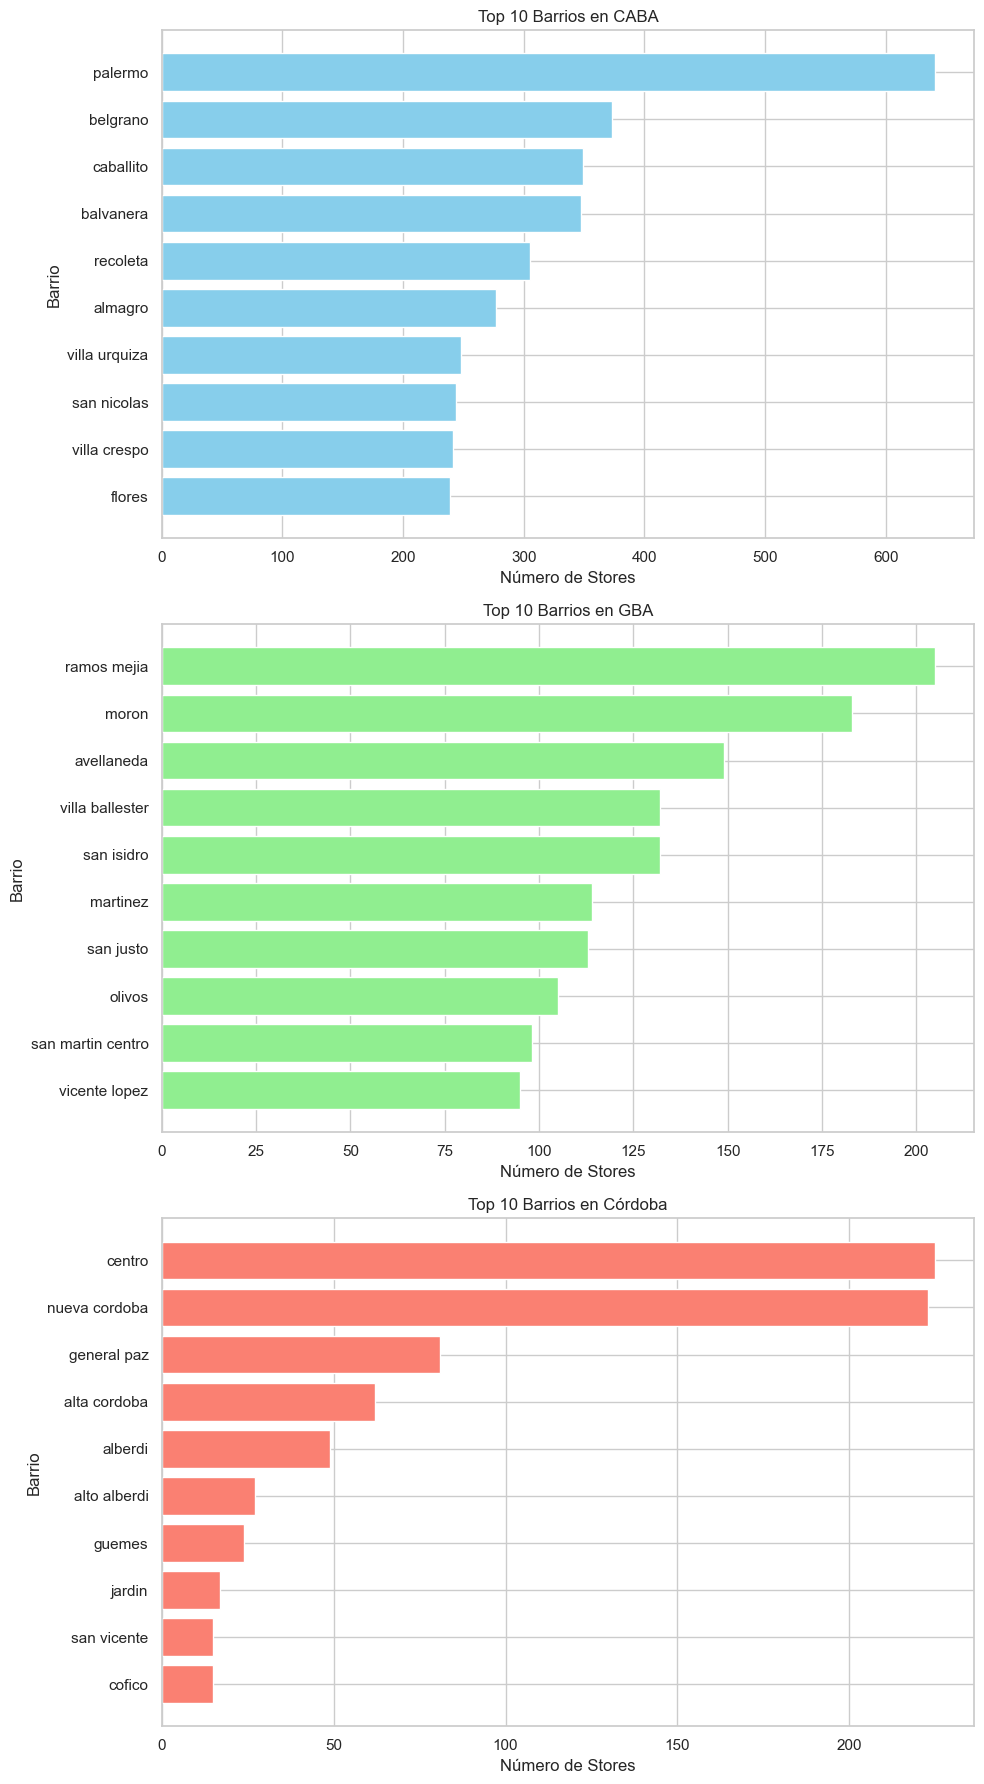

In [358]:
# 3. Dividir las tablas por ciudad (CABA, GBA, y Córdoba)
caba_barrio_counts = barrio_counts[barrio_counts['ciudad'] == 'CABA']
gba_barrio_counts = barrio_counts[barrio_counts['ciudad'] == 'GBA']
cordoba_barrio_counts = barrio_counts[barrio_counts['ciudad'] == 'Córdoba']

# Mostrar las tablas de cada ciudad
print("CABA Barrio Counts:")
display(caba_barrio_counts)

print("\nGBA Barrio Counts:")
display(gba_barrio_counts)

print("\nCórdoba Barrio Counts:")
display(cordoba_barrio_counts)

# 4. Gráficos de los top 10 barrios de cada ciudad
top_10_caba = caba_barrio_counts.nlargest(10, 'count').sort_values('count', ascending=True)
top_10_gba = gba_barrio_counts.nlargest(10, 'count').sort_values('count', ascending=True)
top_10_cordoba = cordoba_barrio_counts.nlargest(10, 'count').sort_values('count', ascending=True)

# Plot para cada ciudad
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# CABA
axes[0].barh(top_10_caba['barrio'], top_10_caba['count'], color='skyblue')
axes[0].set_title('Top 10 Barrios en CABA')
axes[0].set_xlabel('Número de Stores')
axes[0].set_ylabel('Barrio')

# GBA
axes[1].barh(top_10_gba['barrio'], top_10_gba['count'], color='lightgreen')
axes[1].set_title('Top 10 Barrios en GBA')
axes[1].set_xlabel('Número de Stores')
axes[1].set_ylabel('Barrio')

# Córdoba
axes[2].barh(top_10_cordoba['barrio'], top_10_cordoba['count'], color='salmon')
axes[2].set_title('Top 10 Barrios en Córdoba')
axes[2].set_xlabel('Número de Stores')
axes[2].set_ylabel('Barrio')

plt.tight_layout()
plt.show()

In [359]:
# Procesamiento del dataframe orders
orders['store_id'] = orders['store_id'].fillna(0).astype(int).astype(str)

# Procesamiento del dataframe stages
# Replace NaN with a placeholder value (e.g., -1), convert to integers, and then to strings
stages['store_id'] = stages['store_id'].fillna(-1).astype(float).astype('Int64').astype(str)

# Optionally, replace the placeholder value back to NaN after conversion
stages['store_id'] = stages['store_id'].replace('-1', np.nan)

# Exploratory Analysis

### Churn column

In [360]:
import logging

logger = logging.getLogger("churn_builder")
if not logger.handlers:
    _h = logging.StreamHandler()
    _fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    _h.setFormatter(_fmt)
    logger.addHandler(_h)
logger.setLevel(logging.INFO)

def construir_df_churn_mensual(
    stores: pd.DataFrame,
    orders: pd.DataFrame,
    *,
    start_ym: str = "2024-01",           # desde enero 2024
    end_ym: str | None = None,           # si None usa el max de tus datos
    store_id_col: str = "store_id",
    created_col: str = "created_date",
    tpn_col: str = "tpn",                # si no existe, intenta 'TPN'
    order_date_col: str | None = None,   # si orders es diario, nombre de la columna fecha (p.ej. 'order_date' o 'analyzed_day')
    year_col: str | None = None,         # si ya tenés year/month en orders, podés pasarlos
    month_col: str | None = None,
    incluir_meses_pre_alta: bool = True  # True = incluir meses previos al alta con churn=0
) -> pd.DataFrame:
    """
    Devuelve un DataFrame con columnas: store_id, year, month, tpn, churn.
    Reglas de churn:
      - Si un store no vende un mes => churn=1.
      - Si dos meses seguidos sin venta => ambos meses churn=1.
      - Patrón 0,1,1 (no vendió, vendió, vendió) => el tercer mes también churn=1.
      - Antes de created_date nunca marcar churn.

    Maneja orders diario o ya mensual; agrega TPN a nivel (store_id, year, month).
    """
    logger.info("Normalizando columnas y tipos...")
    s = stores.copy()
    o = orders.copy()

    # Validaciones básicas
    for df_name, df, col in [("stores", s, store_id_col), ("orders", o, store_id_col)]:
        if col not in df.columns:
            raise ValueError(f"Columna '{col}' no encontrada en {df_name}.")

    # Unificar dtype de store_id (int si se puede, sino str)
    try:
        s[store_id_col] = pd.to_numeric(s[store_id_col], errors="raise")
        o[store_id_col] = pd.to_numeric(o[store_id_col], errors="raise")
        id_is_int = True
    except Exception:
        s[store_id_col] = s[store_id_col].astype(str)
        o[store_id_col] = o[store_id_col].astype(str)
        id_is_int = False

    # created_date → mes de alta
    if created_col not in s.columns:
        raise ValueError(f"Columna '{created_col}' no encontrada en stores.")
    s[created_col] = pd.to_datetime(s[created_col], errors="coerce")
    s["created_month"] = s[created_col].values.astype("datetime64[M]")

    # TPN
    if tpn_col not in o.columns:
        if "TPN" in o.columns:
            tpn_col = "TPN"
        else:
            raise ValueError("No se encontró columna de TPN ni 'tpn' ni 'TPN' en orders.")

    # Derivar year/month para orders
    if order_date_col and order_date_col in o.columns:
        o[order_date_col] = pd.to_datetime(o[order_date_col], errors="coerce")
        o["year"] = o[order_date_col].dt.year
        o["month"] = o[order_date_col].dt.month
    elif (year_col and month_col and year_col in o.columns and month_col in o.columns):
        o["year"] = o[year_col].astype(int)
        o["month"] = o[month_col].astype(int)
    else:
        if not (("year" in o.columns) and ("month" in o.columns)):
            raise ValueError("Proveé 'order_date_col' o ('year','month') en orders.")

    # Agregación mensual
    logger.info("Agregando TPN mensual...")
    o_monthly = (
        o.groupby([store_id_col, "year", "month"], as_index=False)[tpn_col]
         .sum()
    )
    o_monthly["month_ts"] = pd.to_datetime(dict(year=o_monthly["year"], month=o_monthly["month"], day=1))
    o_monthly = o_monthly[[store_id_col, "month_ts", tpn_col]].rename(columns={"month_ts": "month"})

    # Rango de meses
    start_ts = pd.to_datetime(f"{start_ym}-01")
    if end_ym is None:
        max_orders_month = o_monthly["month"].max() if not o_monthly.empty else start_ts
        max_created = s["created_month"].max()
        end_ts = max(filter(pd.notna, [max_orders_month, max_created, start_ts]))
    else:
        end_ts = pd.to_datetime(f"{end_ym}-01")

    months = pd.date_range(start=start_ts, end=end_ts, freq="MS")

    # Grid store × month
    logger.info("Construyendo grilla completa store × mes...")
    all_store_ids = s[store_id_col].dropna().unique()
    base = pd.MultiIndex.from_product([all_store_ids, months], names=[store_id_col, "month"]).to_frame(index=False)

    # Merge de alta
    base = base.merge(s[[store_id_col, "created_month"]], on=store_id_col, how="left")
    base["is_active_month"] = base["month"] >= base["created_month"]

    if not incluir_meses_pre_alta:
        base = base[base["is_active_month"]].copy()

    # Merge TPN mensual
    df = base.merge(o_monthly, on=[store_id_col, "month"], how="left")
    df[tpn_col] = df[tpn_col].fillna(0).astype(int)

    # Vendió (solo cuenta si el mes es posterior/igual al alta)
    df["sold"] = (df[tpn_col] > 0) & df["is_active_month"]

    # Cálculo de churn por store
    logger.info("Aplicando reglas de churn...")
    def _calc_churn(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values("month").copy()
        sold = g["sold"].astype(bool)
        active = g["is_active_month"].astype(bool)

        # Regla base: cualquier mes sin venta post-alta => churn
        churn_zero = (~sold) & active

        # Patrón 0,1,1 ⇒ churn en el 3er mes
        s_lag1 = sold.shift(1, fill_value=False)
        s_lag2 = sold.shift(2, fill_value=False)
        a_lag1 = active.shift(1, fill_value=False)
        a_lag2 = active.shift(2, fill_value=False)
        pattern_0_1_1 = sold & s_lag1 & (~s_lag2) & active & a_lag1 & a_lag2

        g["churn"] = np.where(churn_zero | pattern_0_1_1, 1, 0)
        return g

    out = df.groupby(store_id_col, group_keys=False).apply(_calc_churn)

    # year / month num
    out["year"] = out["month"].dt.year.astype(int)
    out["month_num"] = out["month"].dt.month.astype(int)

    # Selección y tipos finales
    result = out[[store_id_col, "year", "month_num", tpn_col, "churn"]].rename(
        columns={"month_num": "month", tpn_col: "tpn"}
    ).sort_values([store_id_col, "year", "month"])

    if id_is_int:
        result[store_id_col] = result[store_id_col].astype(int)

    logger.info("Listo: dataframe mensual con churn construido.")
    return result


In [361]:
df_final = construir_df_churn_mensual(
    stores=stores,
    orders=orders,
    year_col="year",
    month_col="month",
    tpn_col="tpn",
    incluir_meses_pre_alta=False   
)

2025-09-27 12:42:37,994 | INFO | Normalizando columnas y tipos...
2025-09-27 12:42:37,994 | INFO | Normalizando columnas y tipos...
2025-09-27 12:42:38,594 | INFO | Agregando TPN mensual...
2025-09-27 12:42:38,594 | INFO | Agregando TPN mensual...
2025-09-27 12:42:38,692 | INFO | Construyendo grilla completa store × mes...
2025-09-27 12:42:38,692 | INFO | Construyendo grilla completa store × mes...
2025-09-27 12:42:38,727 | INFO | Aplicando reglas de churn...
2025-09-27 12:42:38,727 | INFO | Aplicando reglas de churn...
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/1403292855.py:138: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = df.groupby(store_id_col, group_keys=False).apply

In [362]:
df_final.head(20)

,store_id,year,month,tpn,churn
39765,100000,2024,10,0,1
39766,100000,2024,11,10,0
39767,100000,2024,12,100,1
39768,100000,2025,1,78,0
39769,100000,2025,2,48,0
39770,100000,2025,3,22,0
39771,100000,2025,4,116,0
39772,100000,2025,5,10,0
39773,100000,2025,6,12,0
39774,100000,2025,7,40,0


In [363]:
# Ejemplo para chequear
store_id = '100000'
year = 2024
month = 10

tpn_value = orders.loc[
    (orders['store_id'] == store_id) & 
    (orders['year'] == year) & 
    (orders['month'] == month), 
    'TPN'
]

if not tpn_value.empty:
    print(f"TPN for store_id {store_id} in {month}/{year}: {tpn_value.iloc[0]}")
else:
    print(f"No data found for store_id {store_id} in {month}/{year}.")

No data found for store_id 100000 in 10/2024.


Agregamos las columnas de stages

In [364]:
def _period_from_year_month(df, year_col="year", month_col="month"):
    return pd.to_datetime(
        df[year_col].astype(int).astype(str) + "-" +
        df[month_col].astype(int).astype(str) + "-01",
        errors="coerce"
    ).dt.to_period("M")

def recomputar_churn_usando_primer_venta(
    df_final: pd.DataFrame,
    stores: pd.DataFrame,
    *,
    store_id_col="store_id",
    created_col="created_date",
    year_col="year",
    month_col="month",
    tpn_col="tpn",
    churn_col="churn"
) -> pd.DataFrame:
    """
    Define el 'mes de alta real' como el primer mes con tpn>0 en df_final.
    Si el store nunca vendió, usa stores.created_date (si existe) como respaldo.

    Reglas de churn:
      - Pre-alta: churn = NaN
      - Post/desde alta: churn = 1 si tpn==0, si no 0
    """
    df = df_final.copy()

    # Periodo mensual en df_final
    df["_period"] = _period_from_year_month(df, year_col, month_col)

    # Primer mes con ventas por store (alta real)
    ventas_pos = df[df[tpn_col].fillna(0) > 0].copy()
    first_sale = (ventas_pos.groupby(store_id_col)["_period"]
                  .min()
                  .rename("go_live_month"))

    # Respaldo: created_date -> month
    st = stores[[store_id_col]].copy()
    if created_col in stores.columns:
        st[created_col] = pd.to_datetime(stores[created_col], errors="coerce")
        st["created_month"] = st[created_col].dt.to_period("M")
    else:
        st["created_month"] = pd.Period("2262-04")  # futuro, actúa como "sin dato"

    # Unir go_live (preferir primer venta; si no, created_month)
    st = st.merge(first_sale, on=store_id_col, how="left")
    st["go_live_month"] = st["go_live_month"].fillna(st["created_month"])

    df = df.merge(st[[store_id_col, "go_live_month"]], on=store_id_col, how="left")

    # Asignar churn
    df[churn_col] = np.nan  # por defecto pre-alta
    m = df["go_live_month"].notna() & (df["_period"] >= df["go_live_month"])
    df.loc[m, churn_col] = (df.loc[m, tpn_col].fillna(0).astype(float) <= 0).astype(int)

    # Limpieza
    df = df.drop(columns=["_period"])
    return df

def asignar_stage_con_buckets(
    df_final: pd.DataFrame,
    *,
    store_id_col="store_id",
    year_col="year",
    month_col="month",
    tpn_col="tpn",
    churn_col="churn"
) -> pd.DataFrame:
    """
    STAGE:
      - New: primer mes con tpn>0 (post alta)
      - Retained: tpn>0 y venía con tpn>0
      - Reactivated: tpn>0, venía con tpn==0 y ya hubo algún tpn>0 antes
      - Churn: primer mes de racha con tpn==0 (post alta)
      - Churn <3m: 2do o 3er mes consecutivo sin ventas
      - Churn >3m: 4+ meses consecutivos sin ventas
      - Pre-alta (churn NaN): STAGE = ""
    """
    df = df_final.copy()

    # Orden temporal
    df["_ts"] = pd.to_datetime(
        df[year_col].astype(int).astype(str) + "-" +
        df[month_col].astype(int).astype(str) + "-01",
        errors="coerce"
    )
    df = df.sort_values([store_id_col, "_ts"]).reset_index(drop=True)

    # Flags
    pre_alta = df[churn_col].isna()
    df["_active"] = (df[tpn_col].fillna(0) > 0).astype(int)
    df["_active_lag1"] = df.groupby(store_id_col)["_active"].shift(1).fillna(0).astype(int)
    df["_ever_active_before"] = (
        df.groupby(store_id_col)["_active"]
          .transform(lambda s: s.shift(1).fillna(0).cummax())
          .astype(int)
    )

    # Racha de meses consecutivos sin ventas (solo post-alta)
    df["_zero"] = ((df[tpn_col].fillna(0) <= 0) & (~pre_alta)).astype(int)
    df["_block"] = df.groupby(store_id_col)["_zero"].transform(lambda s: (s == 0).cumsum())
    df["_zero_run"] = df.groupby([store_id_col, "_block"])["_zero"].cumsum().astype(int)

    # Reglas de stage
    is_new          = (df["_active"].eq(1) & df["_ever_active_before"].eq(0) & (~pre_alta))
    is_retained     = (df["_active"].eq(1) & df["_active_lag1"].eq(1) & (~pre_alta))
    is_reactivated  = (df["_active"].eq(1) & df["_active_lag1"].eq(0) & df["_ever_active_before"].eq(1) & (~pre_alta))
    is_churn_first  = (df["_active"].eq(0) & df["_zero_run"].eq(1) & (~pre_alta))        # *** primer mes de churn
    is_churn_2_3    = (df["_active"].eq(0) & df["_zero_run"].between(2, 3) & (~pre_alta))
    is_churn_4p     = (df["_active"].eq(0) & df["_zero_run"].ge(4) & (~pre_alta))

    df["STAGE"] = np.select(
        [is_new, is_retained, is_reactivated, is_churn_first, is_churn_2_3, is_churn_4p],
        ["New", "Retained", "Reactivated", "Churn", "Churn <3m", "Churn >3m"],
        default=""  # pre-alta u otros
    )

    # Limpieza
    df = df.drop(columns=["_ts", "_active", "_active_lag1",
                          "_ever_active_before", "_zero", "_block", "_zero_run"])
    return df



In [365]:
stores['store_id'] = stores['store_id'].astype(str)
df_final['store_id'] = df_final['store_id'].astype(str)

# A) Recalcular churn usando PRIMERA VENTA como alta real (fallback a created_date)
df_fixed = recomputar_churn_usando_primer_venta(
    df_final, stores,
    store_id_col="store_id",
    created_col="created_date",
    year_col="year",
    month_col="month",
    tpn_col="tpn",
    churn_col="churn"
)

# B) Asignar STAGE con 'Churn' en primer mes de racha y buckets posteriores
df_fixed = asignar_stage_con_buckets(
    df_fixed,
    store_id_col="store_id",
    year_col="year",
    month_col="month",
    tpn_col="tpn",
    churn_col="churn"
)

# (Opcional) Reemplazar df_final
df_final = df_fixed

Revisamos algunos casos

In [366]:
# (Opcional) chequeo rápido en un store
sid = '114246'  # cambiá por el que quieras
print(
    df_final.loc[df_final["store_id"]==sid, ["store_id","year","month","tpn","churn","STAGE"]]
            .sort_values(["year","month"])
            .to_string(index=False)
)


store_id  year  month  tpn  churn     STAGE
  114246  2025      1    0    NaN          
  114246  2025      2  124    0.0       New
  114246  2025      3  336    0.0  Retained
  114246  2025      4    0    1.0     Churn
  114246  2025      5    0    1.0 Churn <3m
  114246  2025      6    0    1.0 Churn <3m
  114246  2025      7    0    1.0 Churn >3m
  114246  2025      8    0    1.0 Churn >3m
  114246  2025      9    0    1.0 Churn >3m


In [367]:

# --- 1) Buscar stores con alta en enero 2025 ---
stores = stores.copy()
stores["created_date"] = pd.to_datetime(stores["created_date"], errors="coerce")
stores["_created_month"] = stores["created_date"].dt.to_period("M")

candidatos = stores.loc[stores["_created_month"] == pd.Period("2025-01"), "store_id"]

print(f"Stores dados de alta en ENE-2025: {candidatos.nunique()} encontrados")
print("Algunos store_id:", candidatos.dropna().head(10).tolist())

Stores dados de alta en ENE-2025: 430 encontrados
Algunos store_id: ['114246', '111592', '102489', '101616', '109423', '108825', '110758', '113043', '103164', '109859']


### Alta de stores

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/1101711901.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['created_date'] = pd.to_datetime(stores_acotado['created_date'])
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/1101711901.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['year_opened'] = stores_acotado['created_date'].dt.year
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/1101711901.py:19: SettingWithCopyWarni

Stores dados de alta por año:
   year_opened  store_count
0         2024         3895
1         2025         6069


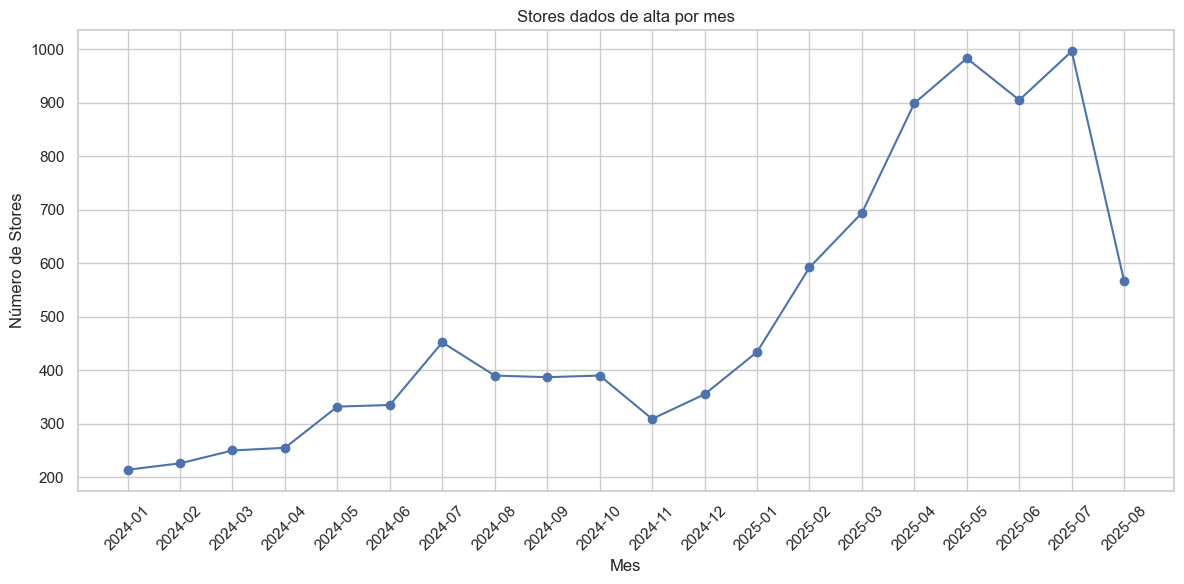


Stores dados de alta por trimestre:
  quarter_opened  store_count
0         2024Q1          690
1         2024Q2          922
2         2024Q3         1229
3         2024Q4         1054
4         2025Q1         1720
5         2025Q2         2787
6         2025Q3         1562


/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/1101711901.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['quarter_opened'] = stores_acotado['created_date'].dt.to_period('Q')
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/1101711901.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores_acotado['day_of_week_opened'] = stores_acotado['created_date'].dt.day_name()


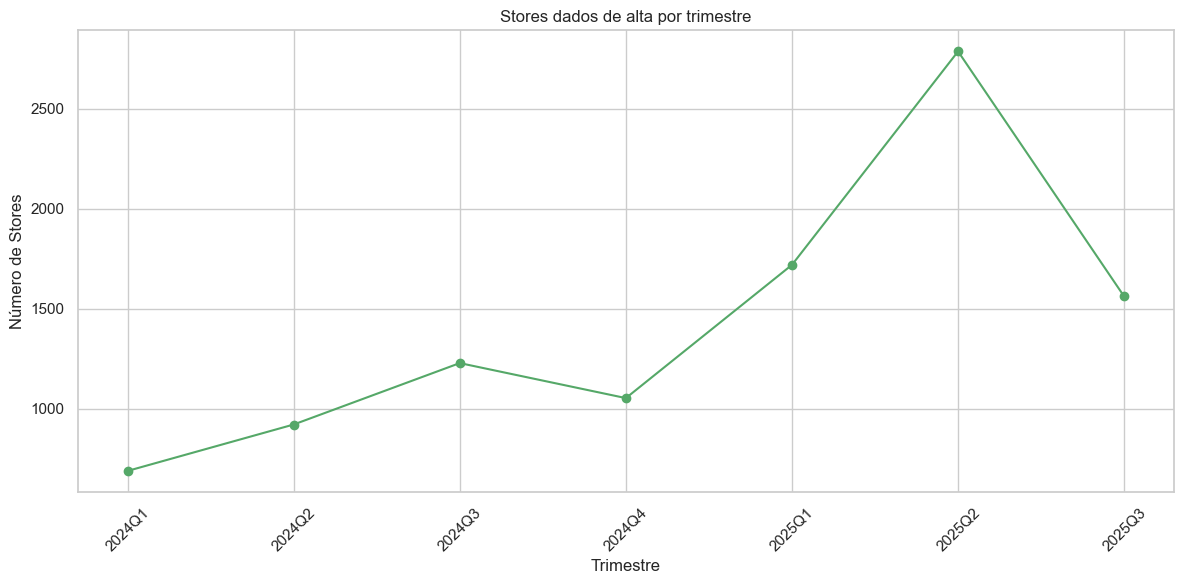

In [370]:
# vemos solo hasta agosto 2025 porque como septiembre no está terminado, no tiene sentido analizarlo
from datetime import datetime
comparison_date = datetime.strptime('2025-08-31', '%Y-%m-%d').date()

#  created_date con formato date 
stores['created_date'] = pd.to_datetime(stores['created_date'], errors='coerce').dt.date

# Filtrar stores
stores_acotado = stores[stores['created_date'] <= comparison_date]

stores_acotado['created_date'] = pd.to_datetime(stores_acotado['created_date'])

stores_acotado['year_opened'] = stores_acotado['created_date'].dt.year
stores_per_year = stores_acotado.groupby('year_opened').size().reset_index(name='store_count')

print("Stores dados de alta por año:")
print(stores_per_year)

stores_acotado['month_opened'] = stores_acotado['created_date'].dt.to_period('M')
stores_per_month = stores_acotado.groupby('month_opened').size().reset_index(name='store_count')

plt.figure(figsize=(12, 6))
plt.plot(stores_per_month['month_opened'].astype(str), stores_per_month['store_count'], marker='o', color='b')
plt.title('Stores dados de alta por mes')
plt.xlabel('Mes')
plt.ylabel('Número de Stores')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

stores_acotado['quarter_opened'] = stores_acotado['created_date'].dt.to_period('Q')
stores_per_quarter = stores_acotado.groupby('quarter_opened').size().reset_index(name='store_count')

print("\nStores dados de alta por trimestre:")
print(stores_per_quarter)

stores_acotado['day_of_week_opened'] = stores_acotado['created_date'].dt.day_name()
stores_per_day_of_week = stores_acotado.groupby('day_of_week_opened').size().reset_index(name='store_count')

ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stores_per_day_of_week['day_of_week_opened'] = pd.Categorical(stores_per_day_of_week['day_of_week_opened'], categories=ordered_days, ordered=True)
stores_per_day_of_week = stores_per_day_of_week.sort_values('day_of_week_opened')

plt.figure(figsize=(12, 6))
plt.plot(stores_per_quarter['quarter_opened'].astype(str), stores_per_quarter['store_count'], marker='o', color='g')
plt.title('Stores dados de alta por trimestre')
plt.xlabel('Trimestre')
plt.ylabel('Número de Stores')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Análisis cohorte: detección de calidad de leads

In [378]:
logger = logging.getLogger("cohort_heatmap_counts")
if not logger.handlers:
    logger.setLevel(logging.INFO)
    h = logging.StreamHandler()
    h.setLevel(logging.INFO)
    h.setFormatter(logging.Formatter("[%(asctime)s] %(levelname)s - %(message)s"))
    logger.addHandler(h)

def to_period_month(s):
    """Convierte Serie/array/escalares a Period('M') de forma robusta."""
    return pd.to_datetime(s, errors="coerce").dt.to_period("M")

def age_in_months(obs_period: pd.Series, cohort_period: pd.Series) -> pd.Series:
    """
    Edad en meses entre dos Series de Period('M').
    Evita la resta directa (que puede dar offsets) y calcula por (año*12 + mes).
    """
    obs_p = obs_period.astype("period[M]")
    coh_p = cohort_period.astype("period[M]")
    return ((obs_p.dt.year - coh_p.dt.year) * 12 + (obs_p.dt.month - coh_p.dt.month)).astype("Int64").astype(int)

# Construcción de matriz de cohortes (CON CHURN DE df_final)
def build_cohort_counts_matrix(
    stores: pd.DataFrame,
    df_final: pd.DataFrame,             
    store_id_col: str = "store_id",
    created_col: str = "created_date",
    year_col: str = "year",       
    month_col: str = "month",      
    churn_col: str = "churn",     
    min_cohort_size: int = 1,
):
    """
    Devuelve una matriz (DataFrame) con el conteo de stores ACTIVOS (churn==0) por cohorte (filas) y edad (columnas).
    - age = 0 muestra el tamaño de la cohorte (altas ese mes, segun stores.created_date).
    - age >= 1 muestra cuántos de esa cohorte están con churn==0 en ese mes (lectura PIT).
    
    Requiere:
      - stores[created_date] con la fecha de alta.
      - df_final a nivel mensual con columnas: store_id, year, month, churn (0/1), y opcionalmente tpn.
    """

    logger.info("Normalizando cohortes (mes de alta) y meses de observación…")

    st = stores[[store_id_col, created_col]].dropna().copy()
    st[created_col] = pd.to_datetime(st[created_col], errors="coerce")
    st = st.dropna(subset=[created_col])
    st["cohort_period"] = st[created_col].dt.to_period("M") 

    needed_cols = {store_id_col, year_col, month_col, churn_col}
    missing = needed_cols - set(df_final.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df_final: {missing}")

    dfc = df_final[[store_id_col, year_col, month_col, churn_col]].copy()
    dfc[year_col] = dfc[year_col].astype(int)
    dfc[month_col] = dfc[month_col].astype(int)
    dfc[churn_col] = (
        pd.to_numeric(dfc[churn_col], errors="coerce")   # fuerza numérico; no numérico -> NaN
        .replace([np.inf, -np.inf], np.nan)            # inf -> NaN
        .fillna(0)                                     # NaN -> 0
        .astype(int)
    )
    dfc["obs_period"] = to_period_month(
        pd.to_datetime(
            dfc[year_col].astype(str) + "-" + dfc[month_col].astype(str) + "-01",
            errors="coerce"
        )
    )
    dfc = dfc.dropna(subset=["obs_period"])

    logger.info("Uniendo timeline mensual con cohorte…")
    df = dfc.merge(st[[store_id_col, "cohort_period"]], on=store_id_col, how="left")
    df = df.dropna(subset=["cohort_period"])
    df = df[df["obs_period"] >= df["cohort_period"]].copy()

    logger.info("Calculando edad en meses y flag activo (churn==0)…")
    df["age"] = age_in_months(df["obs_period"], df["cohort_period"])
    df["active_flag"] = (df[churn_col] == 0).astype(int)

    cohort_sizes = (
        st.groupby("cohort_period")[store_id_col]
          .nunique()
          .rename("cohort_size")
    )

    if min_cohort_size > 1:
        valid = cohort_sizes[cohort_sizes >= min_cohort_size].index
        df = df[df["cohort_period"].isin(valid)]
        cohort_sizes = cohort_sizes.loc[valid]

    # --- conteo de ACTIVOS (churn==0) por cohorte-edad
    logger.info("Conteo de activos (churn==0) por cohorte-edad…")
    active_counts = (
        df[df["active_flag"] == 1]
        .groupby(["cohort_period", "age"])[store_id_col]
        .nunique()
        .unstack("age")
        .sort_index()
        .astype(float)
    )

    active_counts[0] = cohort_sizes
    active_counts = active_counts.sort_index(axis=1)

    max_age = int(active_counts.columns.max())
    ages = list(range(0, max_age + 1))
    matrix = active_counts.reindex(columns=ages).sort_index()

    matrix = matrix.applymap(lambda x: np.nan if pd.isna(x) else int(x))
    matrix.index.name = "cohort_period"
    return matrix  

# matriz en proporciones vs tamaño de cohorte
def counts_to_rates(matrix_counts: pd.DataFrame):
    """
    Convierte la matriz de conteos a tasas (% de la cohorte).
    age=0 pasa a 100% (o 1.0).
    """
    if matrix_counts.empty:
        return matrix_counts
    cohort_sizes = matrix_counts[0].astype(float)
    rates = matrix_counts.divide(cohort_sizes, axis=0)
    rates[0] = 1.0
    return rates

# Plot heatmap con números
def plot_cohort_heatmap_counts(matrix: pd.DataFrame, title="Cohortes: Activos por edad (conteos)"):
    """
    Dibuja un heatmap con números por celda.
    """
    if matrix.empty:
        raise ValueError("La matriz está vacía.")

    data = matrix.values.astype(float)
    data = np.ma.masked_invalid(data) 

    fig, ax = plt.subplots(figsize=(12, max(5, 0.35 * len(matrix))))
    vmax = np.nanmax(matrix.values.astype(float))
    norm = Normalize(vmin=0, vmax=max(vmax, 1.0))

    cmap = LinearSegmentedColormap.from_list(
    "retention_green_yellow_red",
    [
        "#2ecc71", 
        "#a3d977",  
        "#f6d55c", 
        "#f39c12",  
        "#e74c3c", 
    ]
)

    im = ax.imshow(data, aspect="auto", norm=norm, cmap=cmap)
    im.cmap.set_bad("white")  # NaN se pintan blanco

    ax.set_title(title, pad=14, fontsize=13, weight="bold")
    ax.set_xlabel("Edad de la cohorte (meses)", labelpad=10)
    ax.set_ylabel("Mes de alta (cohorte)", labelpad=10)

    ylabels = [idx.strftime("%b-%y") for idx in matrix.index.to_timestamp()]
    ax.set_yticks(range(len(ylabels)))
    ax.set_yticklabels(ylabels)

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns.tolist())

    ax.set_xticks(np.arange(-.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.25)
    ax.tick_params(axis='both', which='both', length=0)

    # Anotar números (si no es NaN en la matriz original)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.iat[i, j]
            if not pd.isna(val):
                ax.text(j, i, f"{int(val)}", ha="center", va="center", fontsize=9)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Tiendas activas (conteo)", rotation=90)

    plt.tight_layout()
    plt.show()

# matriz de churners por cohorte-edad
def build_cohort_churners_matrix(
    stores: pd.DataFrame,
    df_final: pd.DataFrame,
    store_id_col: str = "store_id",
    created_col: str = "created_date",
    year_col: str = "year",
    month_col: str = "month",
    churn_col: str = "churn",
    min_cohort_size: int = 1,
):
    """
    Igual que build_cohort_counts_matrix pero cuenta CHURNERS (churn==1) por cohorte-edad.
    """
    logger.info("Normalizando cohortes (mes de alta) y meses de observación…")
    st = stores[[store_id_col, created_col]].dropna().copy()
    st[created_col] = pd.to_datetime(st[created_col], errors="coerce")
    st = st.dropna(subset=[created_col])
    st["cohort_period"] = st[created_col].dt.to_period("M")

    needed_cols = {store_id_col, year_col, month_col, churn_col}
    missing = needed_cols - set(df_final.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df_final: {missing}")

    dfc = df_final[[store_id_col, year_col, month_col, churn_col]].copy()
    dfc[year_col] = dfc[year_col].astype(int)
    dfc[month_col] = dfc[month_col].astype(int)
    dfc[churn_col] = (
        pd.to_numeric(dfc[churn_col], errors="coerce")   # fuerza numérico; no numérico -> NaN
        .replace([np.inf, -np.inf], np.nan)            # inf -> NaN
        .fillna(0)                                     # NaN -> 0
        .astype(int)
    )    
    
    dfc["obs_period"] = to_period_month(
        pd.to_datetime(
            dfc[year_col].astype(str) + "-" + dfc[month_col].astype(str) + "-01",
            errors="coerce"
        )
    )
    dfc = dfc.dropna(subset=["obs_period"])

    logger.info("Uniendo timeline mensual con cohorte…")
    df = dfc.merge(st[[store_id_col, "cohort_period"]], on=store_id_col, how="left")
    df = df.dropna(subset=["cohort_period"])
    df = df[df["obs_period"] >= df["cohort_period"]].copy()

    logger.info("Calculando edad en meses y flag churn (churn==1)…")
    df["age"] = age_in_months(df["obs_period"], df["cohort_period"])
    df["churn_flag"] = (df[churn_col] == 1).astype(int)

    cohort_sizes = (
        st.groupby("cohort_period")[store_id_col]
          .nunique()
          .rename("cohort_size")
    )
    if min_cohort_size > 1:
        valid = cohort_sizes[cohort_sizes >= min_cohort_size].index
        df = df[df["cohort_period"].isin(valid)]
        cohort_sizes = cohort_sizes.loc[valid]

    logger.info("Conteo de churners (churn==1) por cohorte-edad…")
    churn_counts = (
        df[df["churn_flag"] == 1]
        .groupby(["cohort_period", "age"])[store_id_col]
        .nunique()
        .unstack("age")
        .sort_index()
        .astype(float)
    )
    churn_counts[0] = cohort_sizes
    churn_counts = churn_counts.sort_index(axis=1)

    max_age = int(churn_counts.columns.max())
    ages = list(range(0, max_age + 1))
    matrix = churn_counts.reindex(columns=ages).sort_index()

    matrix = matrix.applymap(lambda x: np.nan if pd.isna(x) else int(x))
    matrix.index.name = "cohort_period"
    return matrix


[2025-09-27 13:05:31,400] INFO - Normalizando cohortes (mes de alta) y meses de observación…
2025-09-27 13:05:31,400 | INFO | Normalizando cohortes (mes de alta) y meses de observación…
[2025-09-27 13:05:31,478] INFO - Uniendo timeline mensual con cohorte…
2025-09-27 13:05:31,478 | INFO | Uniendo timeline mensual con cohorte…
[2025-09-27 13:05:31,504] INFO - Calculando edad en meses y flag activo (churn==0)…
2025-09-27 13:05:31,504 | INFO | Calculando edad en meses y flag activo (churn==0)…
[2025-09-27 13:05:31,527] INFO - Conteo de activos (churn==0) por cohorte-edad…
2025-09-27 13:05:31,527 | INFO | Conteo de activos (churn==0) por cohorte-edad…
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/36840392.py:110: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = matrix.applymap(lambda x: np.nan if pd.isna(x) else int(x))


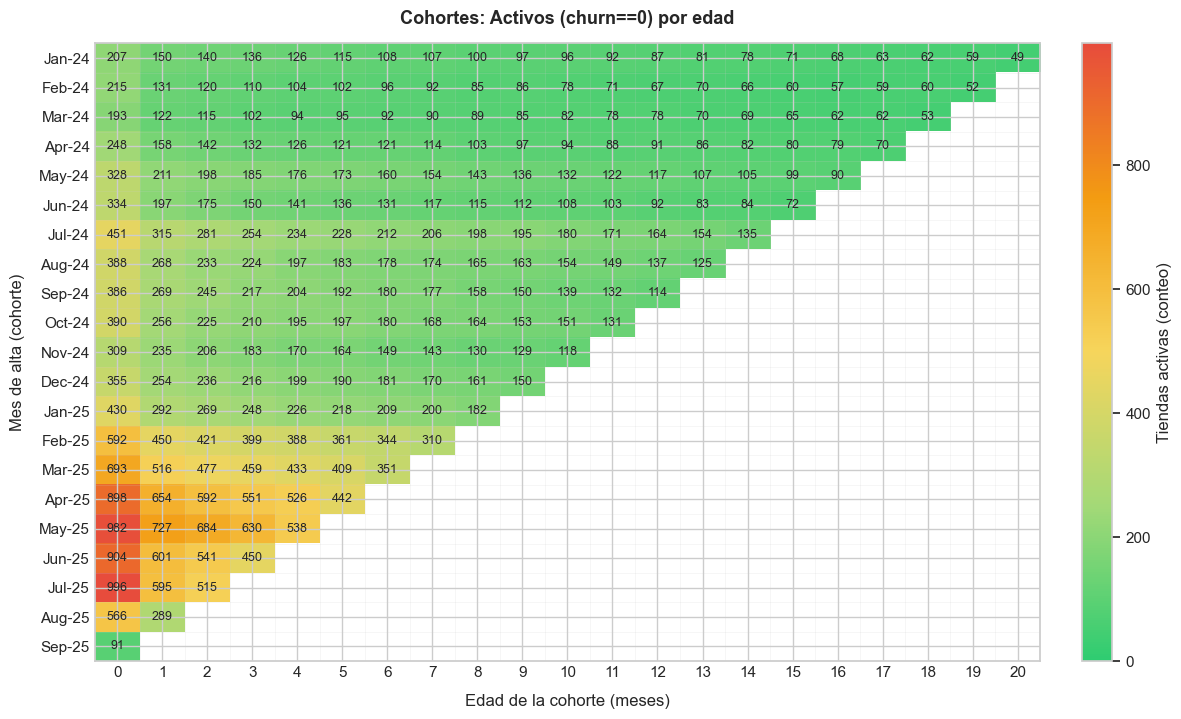

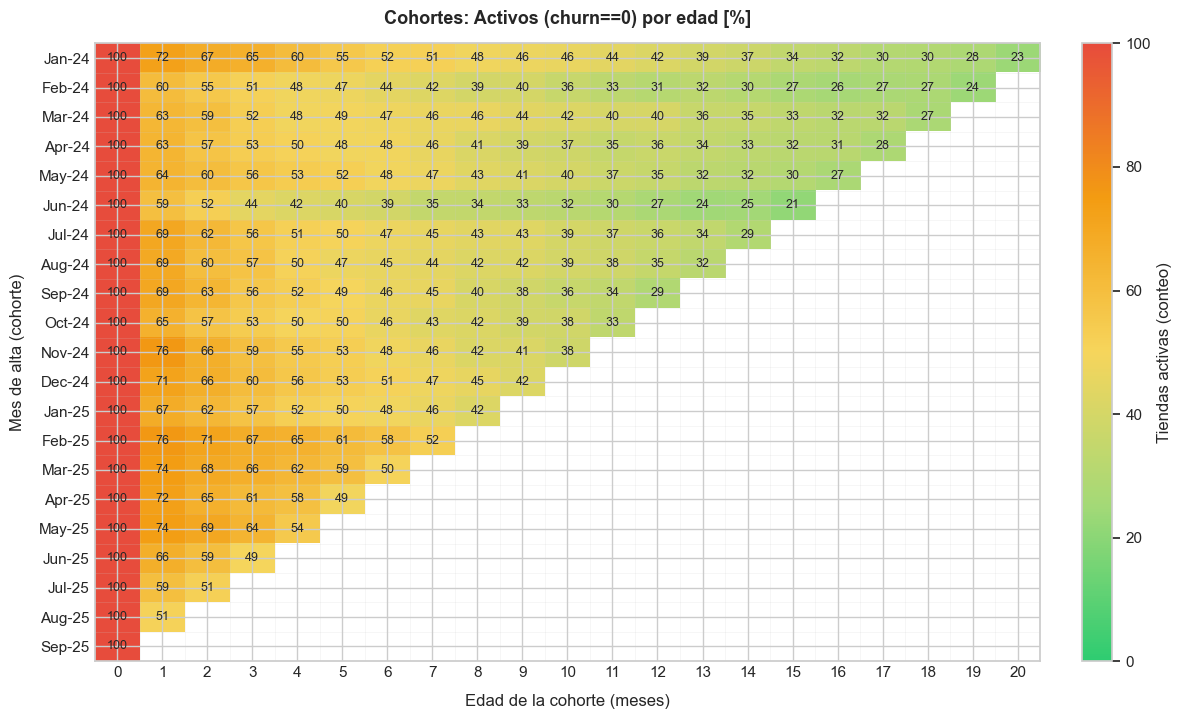

[2025-09-27 13:05:32,128] INFO - Normalizando cohortes (mes de alta) y meses de observación…
2025-09-27 13:05:32,128 | INFO | Normalizando cohortes (mes de alta) y meses de observación…
[2025-09-27 13:05:32,180] INFO - Uniendo timeline mensual con cohorte…
2025-09-27 13:05:32,180 | INFO | Uniendo timeline mensual con cohorte…
[2025-09-27 13:05:32,202] INFO - Calculando edad en meses y flag churn (churn==1)…
2025-09-27 13:05:32,202 | INFO | Calculando edad en meses y flag churn (churn==1)…
[2025-09-27 13:05:32,220] INFO - Conteo de churners (churn==1) por cohorte-edad…
2025-09-27 13:05:32,220 | INFO | Conteo de churners (churn==1) por cohorte-edad…
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/36840392.py:263: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = matrix.applymap(lambda x: np.nan if pd.isna(x) else int(x))


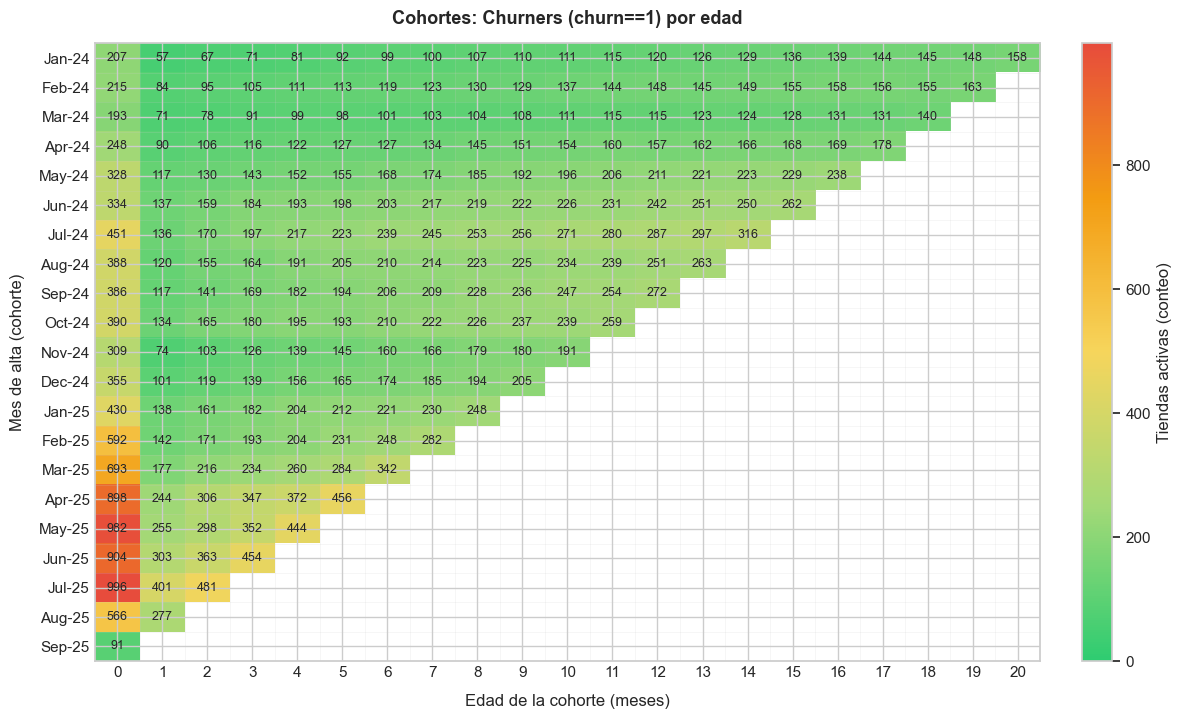

In [379]:
stores["store_id"] = stores["store_id"].astype(str)
df_final["store_id"] = df_final["store_id"].astype(str)

# df_final: columnas = [store_id, year, month, tpn, churn]
matrix_counts = build_cohort_counts_matrix(
    stores=stores,
    df_final=df_final,
    store_id_col="store_id",
    created_col="created_date",
    year_col="year",
    month_col="month",
    churn_col="churn",
    min_cohort_size=10,  # opcional
)

# Heatmap de conteos activos (churn==0)
plot_cohort_heatmap_counts(matrix_counts, title="Cohortes: Activos (churn==0) por edad")

# Opcional: tasas sobre tamaño de cohorte
rates = counts_to_rates(matrix_counts)
plot_cohort_heatmap_counts((rates*100).round(1), title="Cohortes: Activos (churn==0) por edad [%]")

# (Opcional) Matriz de churners
matrix_churners = build_cohort_churners_matrix(stores, df_final)
plot_cohort_heatmap_counts(matrix_churners, title="Cohortes: Churners (churn==1) por edad")


### Stores por segmento

In [381]:
segmento_counts = stores['segmento'].value_counts().reset_index()
segmento_counts.columns = ['segmento', 'count']

print("Cantidad de Stores por Segmento:")
print(segmento_counts)

Cantidad de Stores por Segmento:
        segmento  count
0    Microstores   7064
1    Top Players   1626
2  Picked Locals   1362
3              0      2


Eliminamos los casos de segemnto = 0 (son solo 2 y deben estar sin ssegmento por error)

In [382]:
stores = stores[stores['segmento'] != '0']

print("Filas restantes después de eliminar segmento = 0:")
print(stores['segmento'].value_counts())

Filas restantes después de eliminar segmento = 0:
segmento
Microstores      7064
Top Players      1626
Picked Locals    1362
Name: count, dtype: int64


Visualizamos la cantidad de stores que hay por cada segmento

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/4262788747.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segmento_counts, x='segmento', y='count', palette='viridis')


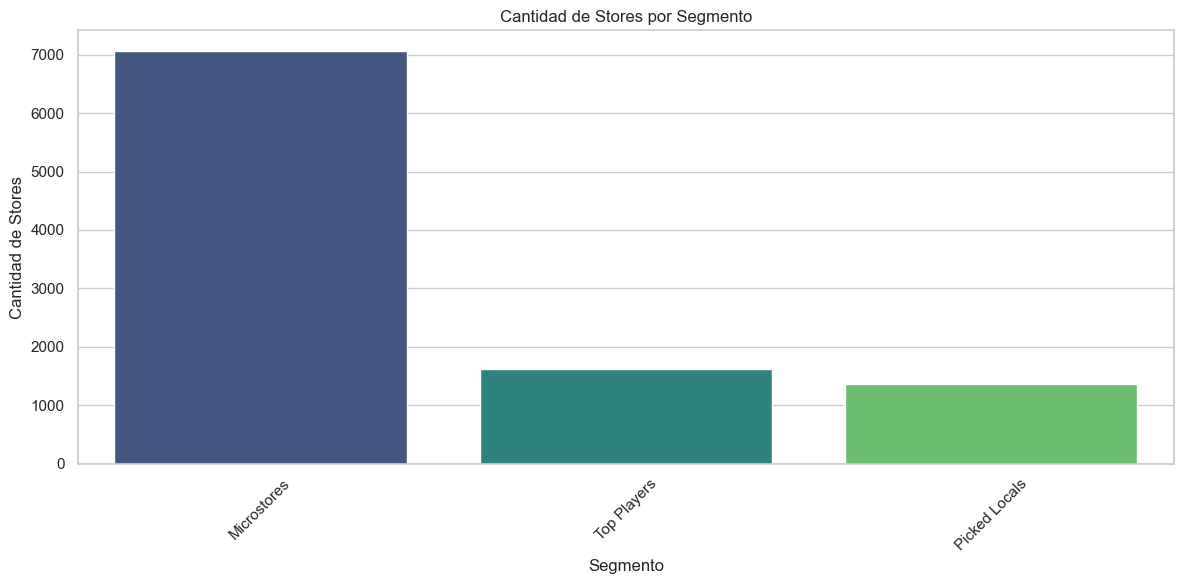

In [383]:
segmento_counts = stores['segmento'].value_counts().reset_index()
segmento_counts.columns = ['segmento', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=segmento_counts, x='segmento', y='count', palette='viridis')
plt.title('Cantidad de Stores por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Cantidad de Stores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Microstores: son las tiendas pequeñas (kioscos, almacenes, etc). Hay mucha cantidad.
- Top Players: son las tiendas que más volumen de ventas aportan. Grandes marcas.
- Picked Locals: son las tiendas que venden mucho pero tienen solo una sucursal, son populares y conocidas en el bario en el que están.

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/2763324368.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_acotado['created_date'] = pd.to_datetime(orders_acotado['created_date'])
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/2763324368.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_acotado['month_year'] = orders_acotado['created_date'].dt.to_period('M')
2025-09-27 13:05:53,658 | INFO | Using categorical units to plot a list of strings that are all 

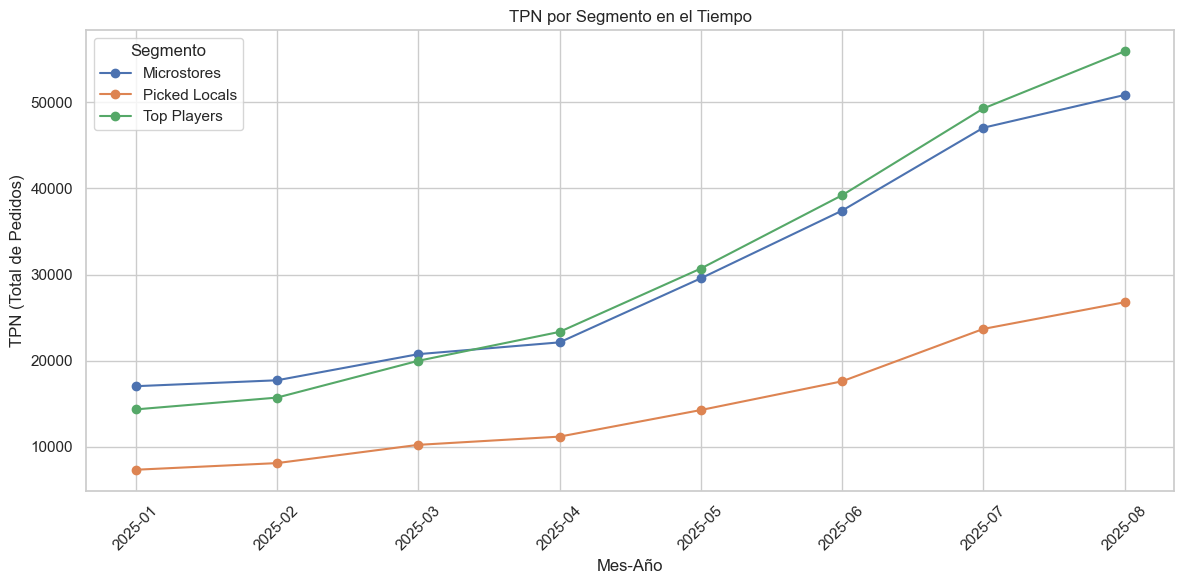

In [384]:
# vemos solo hasta agosto 2025 porque como septiembre no está terminado, no tiene sentido analizarlo
orders_acotado = orders[(orders['created_date'] <= '2025-08-31') & (pd.to_datetime(orders['created_date']).dt.year == 2025)]

orders_acotado['created_date'] = pd.to_datetime(orders_acotado['created_date'])
orders_acotado['month_year'] = orders_acotado['created_date'].dt.to_period('M')

orders_with_segmento = orders_acotado.merge(stores[['store_id', 'segmento']], on='store_id', how='inner')

tpn_per_segmento = orders_with_segmento.groupby(['segmento', 'month_year']).size().reset_index(name='tpn')

tpn_pivot = tpn_per_segmento.pivot(index='month_year', columns='segmento', values='tpn').fillna(0)

plt.figure(figsize=(12, 6))

for segmento in tpn_pivot.columns:
    plt.plot(tpn_pivot.index.astype(str), tpn_pivot[segmento], marker='o', label=f'{segmento}')

plt.title('TPN por Segmento en el Tiempo')
plt.xlabel('Mes-Año')
plt.ylabel('TPN (Total de Pedidos)')
plt.xticks(rotation=45)
plt.legend(title='Segmento')
plt.grid(True)
plt.tight_layout()
plt.show()

En los últimos 3 meses, el segmento Microstores es el que más tiendas en estado de churn tuvo.
Los otros dos segmentos presentaron una suba de churn en el mes de agosto, respecto a los meses anteriores.
Esto tiene en cuenta los casos de 'churn entrante' y 'churn sostenido'; el primer caso es cuando un store entra en churn de un mes a otro y el segundo es cuando ya viene de un mes en churn y continúa este mes en el mismo estado.

Cantidad de churn para segmento en los últimos 3 meses:
segmento  Microstores  Picked Locals  Top Players
month                                            
1                1980            259          148
2                2154            284          191
3                2359            320          218
4                2699            359          270
5                3032            404          314
6                3418            466          371
7                3908            522          436
8                4319            566          479


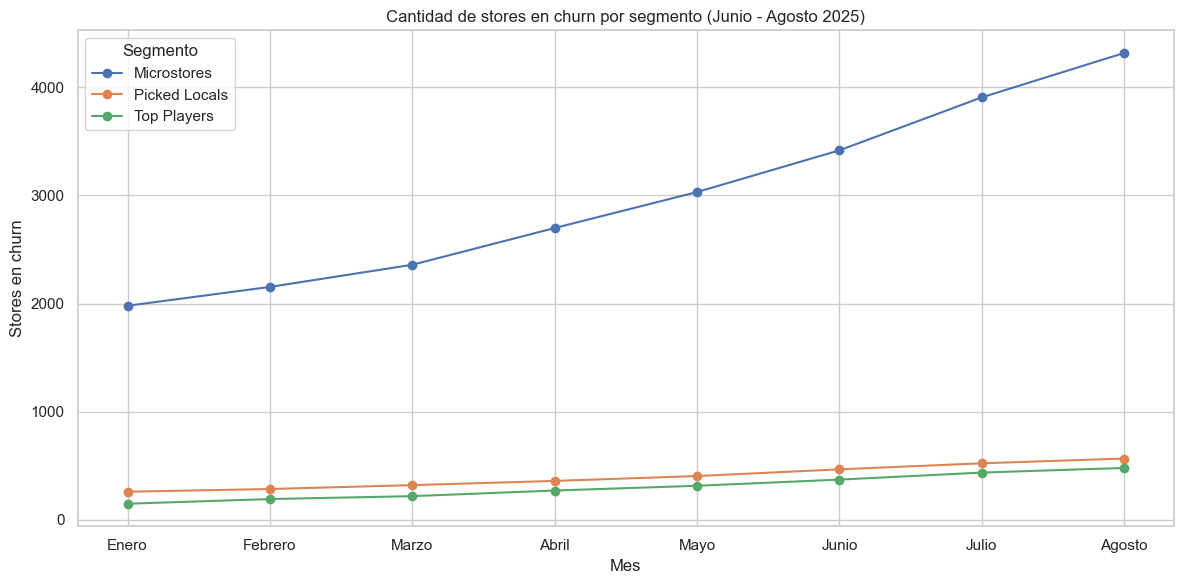

In [385]:
# Filter the df_final dataframe for the months 6, 7, and 8 of 2025
stages_filtered = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([1, 2, 3 ,4, 5,6, 7, 8]))]

# Tomar churn desde df_final (1 = churn)
stages_churn = stages_filtered[stages_filtered['churn'] == 1]

churn_with_segmento = stages_churn.merge(stores[['store_id', 'segmento']], on='store_id', how='inner')

churn_counts = churn_with_segmento.groupby(['month', 'segmento']).size().reset_index(name='churn_count')

churn_pivot = churn_counts.pivot(index='month', columns='segmento', values='churn_count').fillna(0)

print("Cantidad de churn para segmento en los últimos 3 meses:")
print(churn_pivot)

plt.figure(figsize=(12, 6))

for segmento in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[segmento], marker='o', label=f'{segmento}')

plt.title('Cantidad de stores en churn por segmento (Junio - Agosto 2025)')
plt.xlabel('Mes')
plt.ylabel('Stores en churn')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8], ['Enero','Febrero','Marzo','Abril','Mayo' ,'Junio', 'Julio', 'Agosto'])
plt.legend(title='Segmento')
plt.grid(True)
plt.tight_layout()
plt.show()

Cantidad de 'Churn' (primer mes de racha) por segmento en los últimos 3 meses:
segmento  Microstores  Picked Locals  Top Players
month                                            
1                 225             44           48
2                 230             39           45
3                 273             44           31
4                 360             46           54
5                 409             52           49
6                 437             64           62
7                 567             74           74
8                 492             51           51


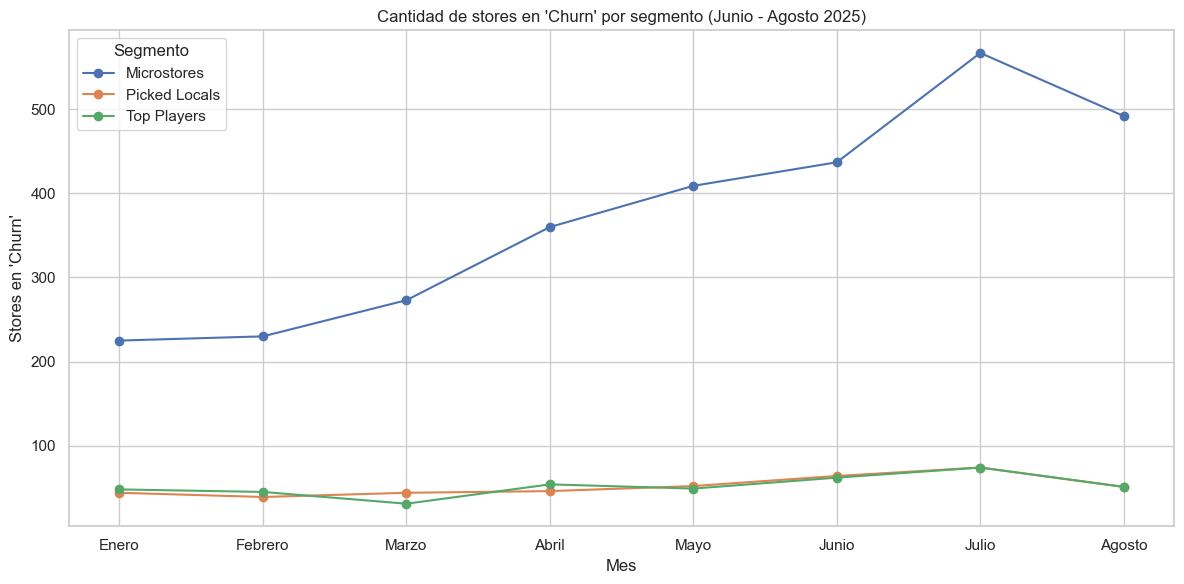

In [386]:
# Filtrar df_final para los meses 6, 7 y 8 de 2025
stages_filtered = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([1, 2, 3 ,4, 5,6, 7, 8]))]

# Tomar SOLO los de primer mes de churn (STAGE == "Churn")
stages_churn = stages_filtered[stages_filtered['STAGE'] == "Churn"]

churn_with_segmento = stages_churn.merge(stores[['store_id', 'segmento']], on='store_id', how='inner')

churn_counts = churn_with_segmento.groupby(['month', 'segmento']).size().reset_index(name='churn_count')

churn_pivot = churn_counts.pivot(index='month', columns='segmento', values='churn_count').fillna(0)

print("Cantidad de 'Churn' (primer mes de racha) por segmento en los últimos 3 meses:")
print(churn_pivot)

plt.figure(figsize=(12, 6))

for segmento in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[segmento], marker='o', label=f'{segmento}')

plt.title("Cantidad de stores en 'Churn' por segmento (Junio - Agosto 2025)")
plt.xlabel('Mes')
plt.ylabel("Stores en 'Churn'")
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8], ['Enero','Febrero','Marzo','Abril','Mayo' ,'Junio', 'Julio', 'Agosto'])
plt.legend(title='Segmento')
plt.grid(True)
plt.tight_layout()
plt.show()


Se nota la diferencia entre ambos tipos de churn, ya que hay muchos stores que vienen en un churn sostenido hace varios meses.

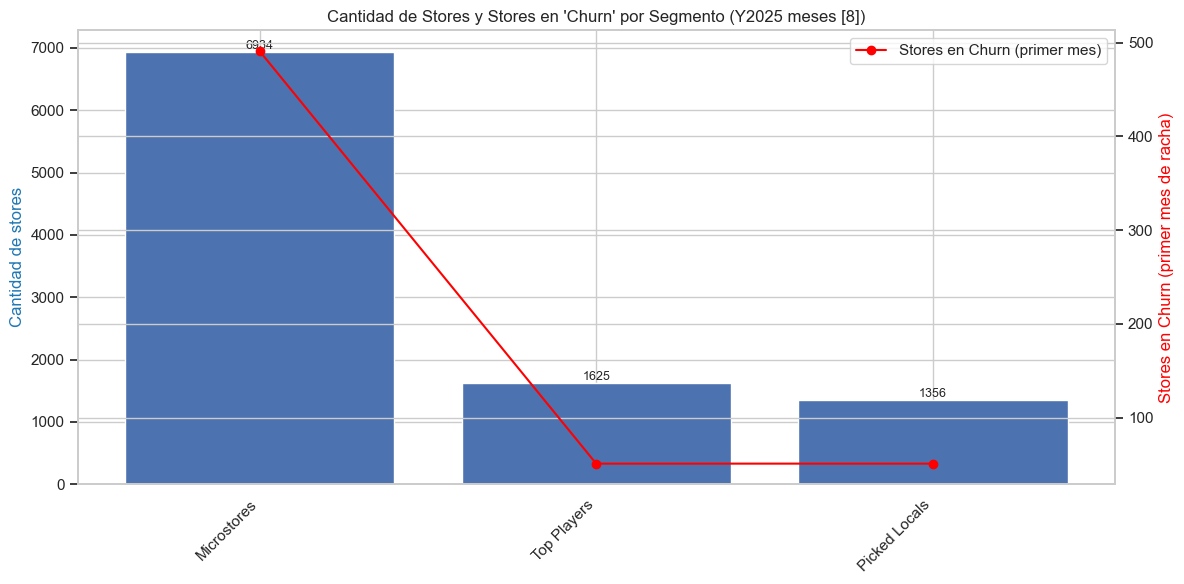

In [387]:
# =========================
# Parámetros del período
# =========================
YEAR = 2025
MONTHS = [8]  # Q2 2025; cambiá si querés otro periodo

# =========================
# Prep base y join segmento
# =========================
dfp = df_final[(df_final["year"] == YEAR) & (df_final["month"].isin(MONTHS))].copy()

# Alinear tipos para el merge
stores_ = stores.copy()
stores_["store_id"] = stores_["store_id"].astype(str)
dfp["store_id"] = dfp["store_id"].astype(str)

dfp = dfp.merge(stores_[["store_id", "segmento"]], on="store_id", how="left")

# =========================
# Métricas por segmento
# =========================
# Cantidad de stores únicos en el período
stores_por_seg = (
    dfp.groupby("segmento")["store_id"]
       .nunique()
       .rename("stores_count")
)

# Cantidad de stores en 'Churn' (primer mes de racha) en el período
churn_first_por_seg = (
    dfp.loc[dfp["STAGE"] == "Churn"]
       .groupby("segmento")["store_id"]
       .nunique()
       .rename("churn_first_count")
)

# Combinar y rellenar faltantes
res = (
    pd.concat([stores_por_seg, churn_first_por_seg], axis=1)
      .fillna(0)
      .astype({"stores_count": int, "churn_first_count": int})
)

# Ordenar por cantidad de stores desc
res = res.sort_values("stores_count", ascending=False)

# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(res))
bar = ax1.bar(x, res["stores_count"])
ax1.set_ylabel("Cantidad de stores", color="tab:blue")
ax1.set_xticks(x, res.index, rotation=45, ha="right")

# Eje derecho (línea roja)
ax2 = ax1.twinx()
ax2.plot(x, res["churn_first_count"], color="red", marker="o", label="Stores en Churn (primer mes)")
ax2.set_ylabel("Stores en Churn (primer mes de racha)", color="red")

# Título
plt.title(f"Cantidad de Stores y Stores en 'Churn' por Segmento (Y{YEAR} meses {MONTHS})")

# Etiquetas encima de las barras (opcional)
for i, v in enumerate(res["stores_count"]):
    ax1.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

# Leyenda para la línea
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


### Stores por categoría

In [388]:
category_counts = stores['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

with pd.option_context('display.max_rows', None): 
    print("Cantidad de Stores por category:")
    print(category_counts)

Cantidad de Stores por category:
                 category  count
0   Desayunos y meriendas   1237
1               Empanadas   1214
2                  Helado    915
3                   Pizza    781
4             Hamburguesa    761
5              Sándwiches    479
6                   Sushi    425
7               Panadería    384
8               Milanesas    381
9               Argentina    360
10          Internacional    330
11              Saludable    275
12          Comida rápida    187
13             Venezolana    181
14                 Pastas    165
15                Bebidas    156
16                   Café    155
17                  Pollo    142
18               Parrilla    138
19              Ensaladas     98
20                Picadas     78
21               Asiática     68
22                  Árabe     68
23                Peruana     64
24                  China     58
25                 Carnes     45
26                Postres     39
27                 Arepas     28
28        

2025-09-27 13:05:55,405 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-09-27 13:05:55,405 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-09-27 13:05:55,406 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-09-27 13:05:55,406 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-09-27 13:05:55,407 | INFO | Using categorical units to plot a list of strings that are all parsable as 

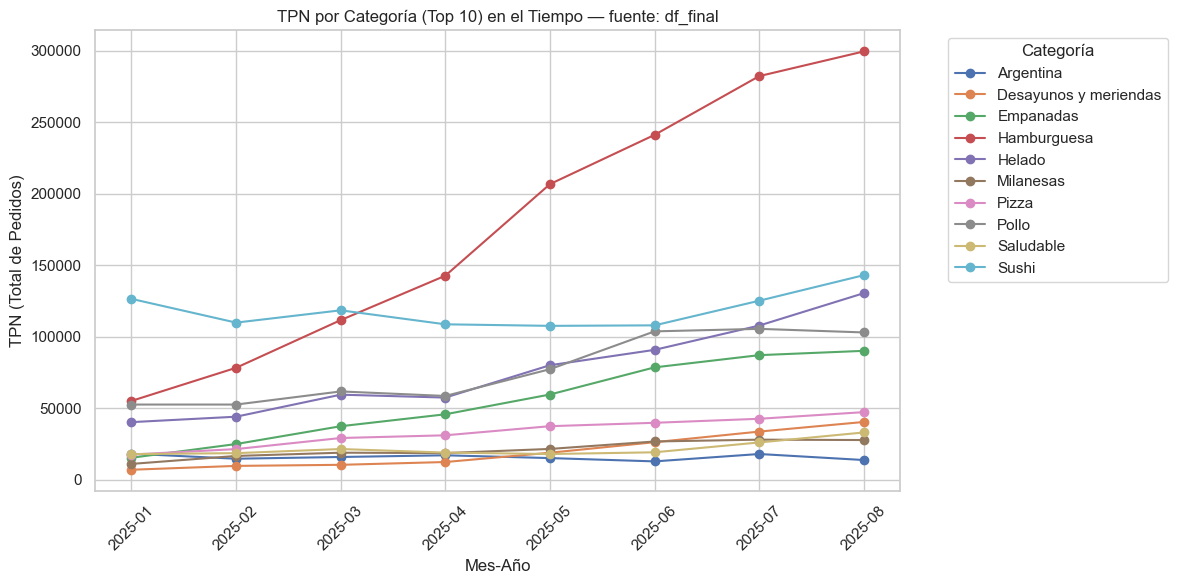

In [ ]:
dfp = df_final[(df_final['year'] == 2025) & (df_final['month'] <= 8)].copy()

dfp['month_year'] = pd.to_datetime(
    dfp['year'].astype(int).astype(str) + '-' + dfp['month'].astype(int).astype(str) + '-01'
).dt.to_period('M')

dfp['store_id'] = dfp['store_id'].astype(str)
stores_ = stores.copy()
stores_['store_id'] = stores_['store_id'].astype(str)

df_merged = dfp.merge(stores_[['store_id', 'category']], on='store_id', how='inner')

tpn_per_category = (
    df_merged.groupby(['category', 'month_year'])['tpn']
             .sum()
             .reset_index()
)

top_10_categories = (
    tpn_per_category.groupby('category')['tpn'].sum()
                    .nlargest(10)
                    .index
)

tpn_top_10 = tpn_per_category[tpn_per_category['category'].isin(top_10_categories)]

tpn_pivot = tpn_top_10.pivot(index='month_year', columns='category', values='tpn').fillna(0)

plt.figure(figsize=(12, 6))
for category in tpn_pivot.columns:
    plt.plot(tpn_pivot.index.astype(str), tpn_pivot[category], marker='o', label=f'{category}')

plt.title('TPN por Categoría (Top 10) en el Tiempo — fuente: df_final')
plt.xlabel('Mes-Año')
plt.ylabel('TPN (Total de Pedidos)')
plt.xticks(rotation=45)
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Cantidad de 'Churn' (primer mes de racha) para las 10 principales categorías (Mar–Ago 2025):
category  Argentina  Desayunos y meriendas  Empanadas  Hamburguesa  Helado  \
month                                                                        
3                16                     33         35           16      49   
4                31                     50         58           28      28   
5                17                     66         64           36      38   
6                13                     79         67           39      70   
7                 9                    108         96           60      55   
8                14                    100         82           65      39   

category  Internacional  Milanesas  Panadería  Pizza  Sándwiches  
month                                                             
3                    11         11         16     23          23  
4                    16         11         21     35          37  
5             

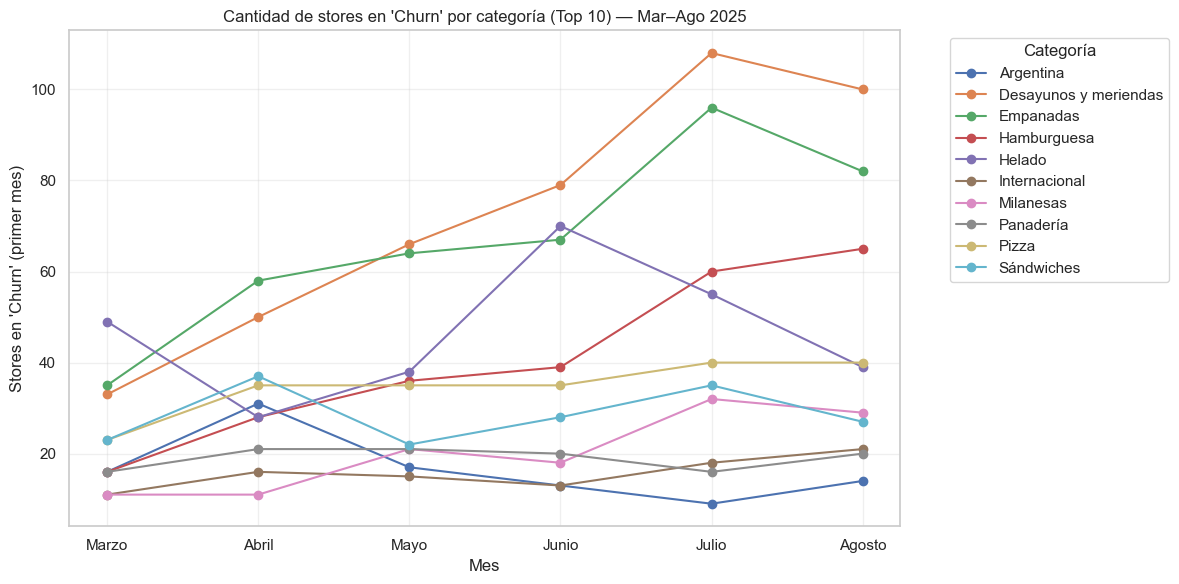

In [ ]:
dfp = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([3, 4, 5, 6, 7, 8]))].copy()

dfp['store_id'] = dfp['store_id'].astype(str)
stores_ = stores.copy()
stores_['store_id'] = stores_['store_id'].astype(str)

df_churn = dfp[dfp['STAGE'] == "Churn"]

churn_with_category = df_churn.merge(stores_[['store_id', 'category']], on='store_id', how='inner')

churn_counts = (
    churn_with_category.groupby(['month', 'category'])
                       .size()
                       .reset_index(name='churn_count')
)

top_10_categories = (
    churn_counts.groupby('category')['churn_count'].sum()
                .nlargest(10)
                .index
)
churn_counts_top_10 = churn_counts[churn_counts['category'].isin(top_10_categories)]

churn_pivot = churn_counts_top_10.pivot(index='month', columns='category', values='churn_count').fillna(0)

print("Cantidad de 'Churn' (primer mes de racha) para las 10 principales categorías (Mar–Ago 2025):")
print(churn_pivot)

plt.figure(figsize=(12, 6))
for category in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[category], marker='o', label=f'{category}')

plt.title("Cantidad de stores en 'Churn' por categoría (Top 10) — Mar–Ago 2025")
plt.xlabel('Mes')
plt.ylabel("Stores en 'Churn' (primer mes)")
plt.xticks([3, 4, 5, 6, 7, 8], ['Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto'])
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Cantidad de 'Churn' (primer mes) para las 10 categorías principales (Mar–Ago 2025):
category  Argentina  Desayunos y meriendas  Empanadas  Hamburguesa  Helado  \
month                                                                        
3                16                     33         35           16      49   
4                31                     50         58           28      28   
5                17                     66         64           36      38   
6                13                     79         67           39      70   
7                 9                    108         96           60      55   
8                14                    100         82           65      39   

category  Internacional  Milanesas  Panadería  Pizza  Sándwiches  
month                                                             
3                    11         11         16     23          23  
4                    16         11         21     35          37  
5                    15

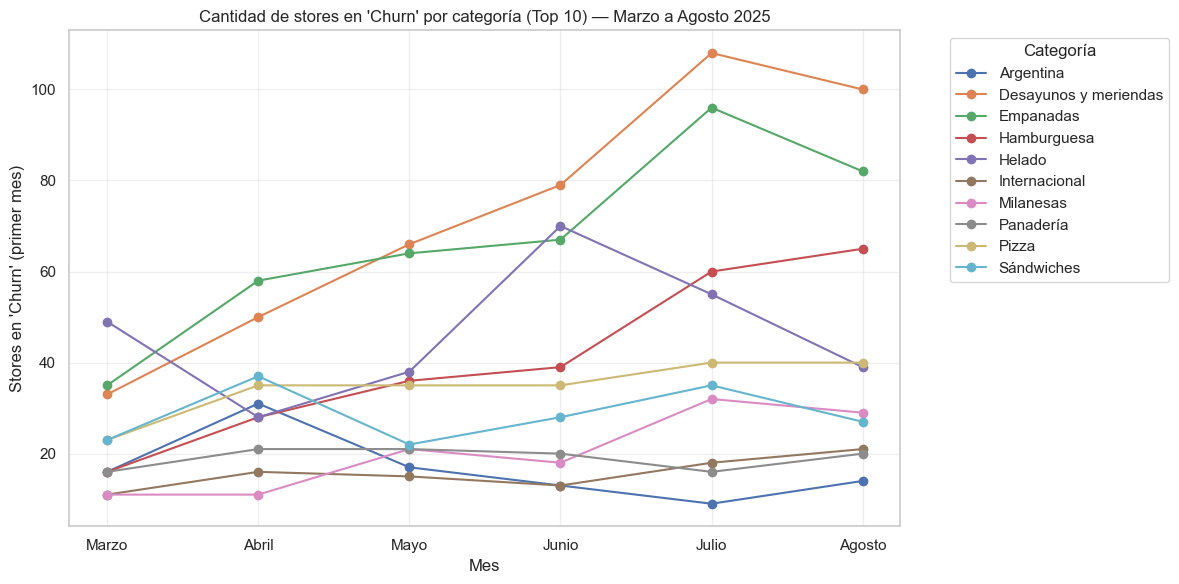

In [ ]:
dfp = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([3, 4, 5, 6, 7, 8]))].copy()

dfp['store_id'] = dfp['store_id'].astype(str)
stores_ = stores.copy()
stores_['store_id'] = stores_['store_id'].astype(str)

df_churn = dfp[dfp['STAGE'] == "Churn"]

churn_with_category = df_churn.merge(stores_[['store_id', 'category']], on='store_id', how='inner')

churn_counts = (
    churn_with_category.groupby(['month', 'category'])
                       .size()
                       .reset_index(name='churn_count')
)

top_n_categories = (
    churn_counts.groupby('category')['churn_count'].sum()
                .nlargest(10)
                .index
)

churn_counts_top = churn_counts[churn_counts['category'].isin(top_n_categories)]

churn_pivot = churn_counts_top.pivot(index='month', columns='category', values='churn_count').fillna(0)

print("Cantidad de 'Churn' (primer mes) para las 10 categorías principales (Mar–Ago 2025):")
print(churn_pivot)

plt.figure(figsize=(12, 6))
for category in churn_pivot.columns:
    plt.plot(churn_pivot.index, churn_pivot[category], marker='o', label=f'{category}')

plt.title("Cantidad de stores en 'Churn' por categoría (Top 10) — Marzo a Agosto 2025")
plt.xlabel('Mes')
plt.ylabel("Stores en 'Churn' (primer mes)")
plt.xticks([3, 4, 5, 6, 7, 8], ['Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto'])
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Las categorías Desayunos y meriendas y Pizza son las que más crecieron en churn entrante en los últimos meses.

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/3164882171.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_categories, y='category', x='churn_count', palette='viridis')


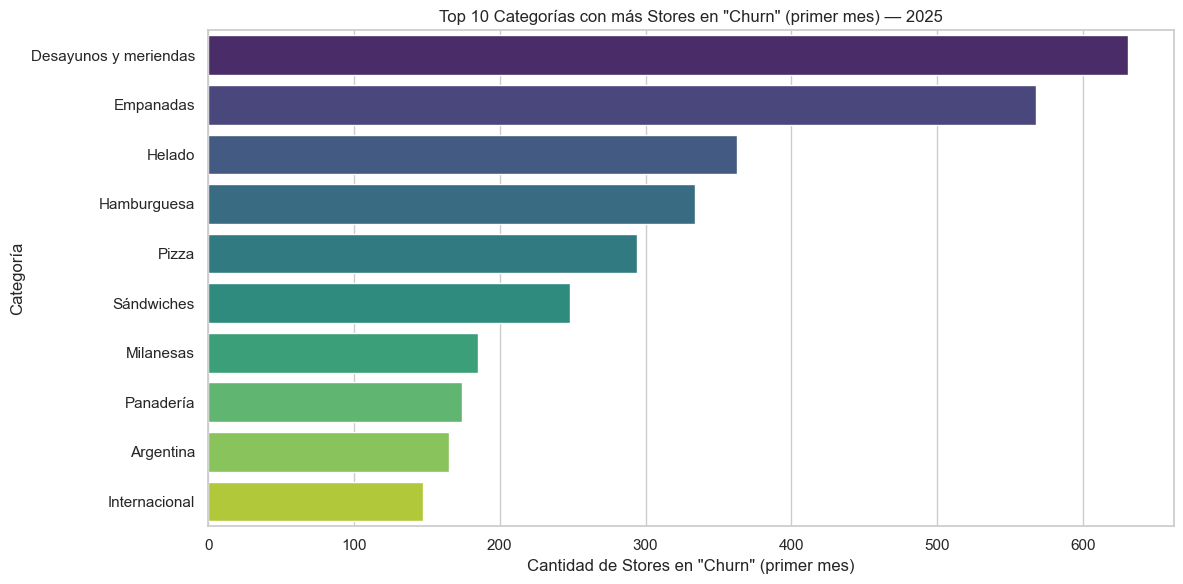

In [ ]:
dfp = df_final[df_final['year'] == 2025].copy()

dfp['store_id'] = dfp['store_id'].astype(str)
stores_ = stores.copy()
stores_['store_id'] = stores_['store_id'].astype(str)

df_churn = dfp[dfp['STAGE'] == "Churn"]

churn_with_category = df_churn.merge(stores_[['store_id', 'category']], on='store_id', how='inner')

churn_counts = (
    churn_with_category.groupby('category')
                       .size()
                       .reset_index(name='churn_count')
                       .sort_values('churn_count', ascending=False)
)
top_10_categories = churn_counts.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_categories, y='category', x='churn_count', palette='viridis')
plt.title('Top 10 Categorías con más Stores en "Churn" (primer mes) — 2025')
plt.xlabel('Cantidad de Stores en "Churn" (primer mes)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

- En lo que va del año, la cetgoría Pizza es la que más stores en churn tuvo (más de 30).
- Desayunos y meriendas sigue, también con un número alto de churn, cercano a 30.

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/2288869545.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined_data, x='category', y='tpn_total', ax=ax1, palette='viridis')
/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/2288869545.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


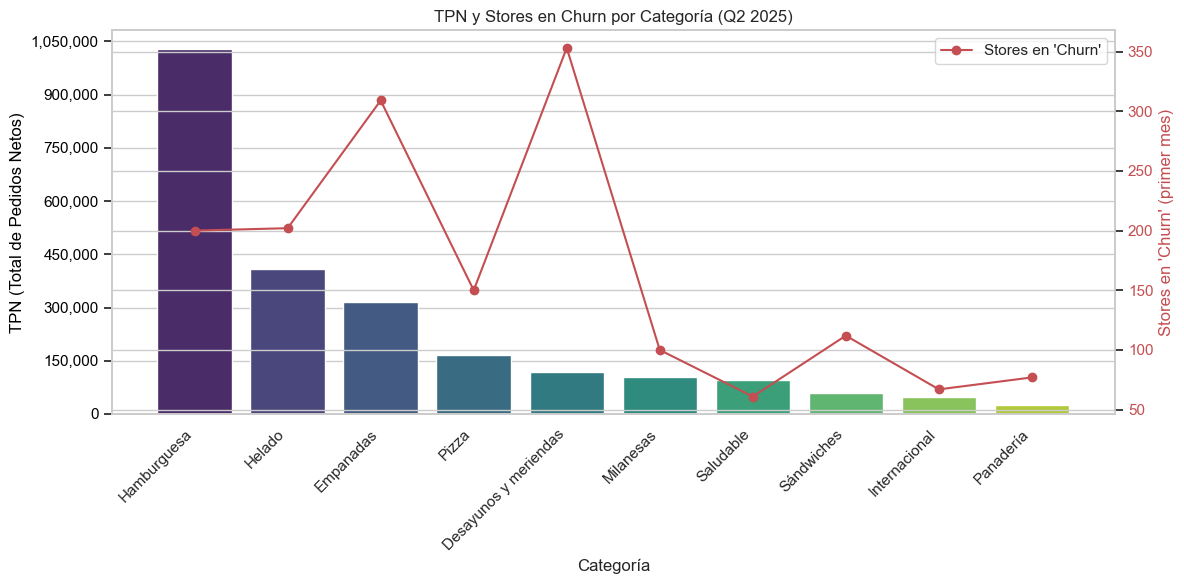

In [393]:
dfc = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([5, 6, 7, 8]))].copy()
dfc['store_id'] = dfc['store_id'].astype(str)

stores_ = stores.copy()
stores_['store_id'] = stores_['store_id'].astype(str)

dfc_churn = dfc[dfc['STAGE'] == 'Churn']

churn_with_category = dfc_churn.merge(stores_[['store_id', 'category']], on='store_id', how='inner')

churn_counts = (
    churn_with_category.groupby('category')
                       .size()
                       .reset_index(name='churn_count')
                       .sort_values('churn_count', ascending=False)
)

top_10_categories = churn_counts.head(10)['category']


dft = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([5, 6, 7, 8]))].copy()
dft['store_id'] = dft['store_id'].astype(str)

dft_cat = dft.merge(stores_[['store_id', 'category']], on='store_id', how='inner')

# TPN total por categoría en el período (sumar tpn mensual de cada store)
tpn_per_category = (
    dft_cat.groupby('category')['tpn']
           .sum()
           .reset_index()
           .rename(columns={'tpn': 'tpn_total'})
)

# Quedarnos con las mismas Top 10 categorías (por churn)
tpn_top_10 = tpn_per_category[tpn_per_category['category'].isin(top_10_categories)]


combined_data = (
    tpn_top_10.merge(churn_counts, on='category', how='left')
              .fillna({'churn_count': 0})
              .sort_values('tpn_total', ascending=False)
)



ffig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=combined_data, x='category', y='tpn_total', ax=ax1, palette='viridis')

# ⬇⬇ Cambios pedidos en el eje Y izquierdo (TPN) ⬇⬇
ax1.set_ylabel('TPN (Total de Pedidos Netos)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))               # ticks en enteros
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))  # formato 1,234

ax1.set_xlabel('Categoría')
ax1.set_title("TPN y Stores en Churn por Categoría (Q2 2025)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(combined_data['category'], combined_data['churn_count'], color='r', marker='o', label="Stores en 'Churn'")
ax2.set_ylabel("Stores en 'Churn' (primer mes)", color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
df_filtered = df_final[(df_final['year'] == 2025) & (df_final['month'].isin([5, 6, 7, 8]))].copy()

df_filtered['store_id'] = df_filtered['store_id'].astype(str)
stores['store_id'] = stores['store_id'].astype(str)

df_merged = df_filtered.merge(stores[['store_id', 'category']], on='store_id', how='inner')

helado_stores = df_merged[df_merged['category'] == 'Helado']

total_tpn_helado = helado_stores['tpn'].sum()

stores_in_churn_helado = helado_stores[helado_stores['STAGE'] == 'Churn']['store_id'].nunique()

print(f"Total TPN for category 'Helado' (May-Aug 2025): {total_tpn_helado}")
print(f"Number of stores in churn for category 'Helado' (May-Aug 2025): {stores_in_churn_helado}")

Total TPN for category 'Helado' (May-Aug 2025): 408928
Number of stores in churn for category 'Helado' (May-Aug 2025): 198


/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/502109327.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stores['store_id'] = stores['store_id'].astype(str)


/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/3771307129.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r")


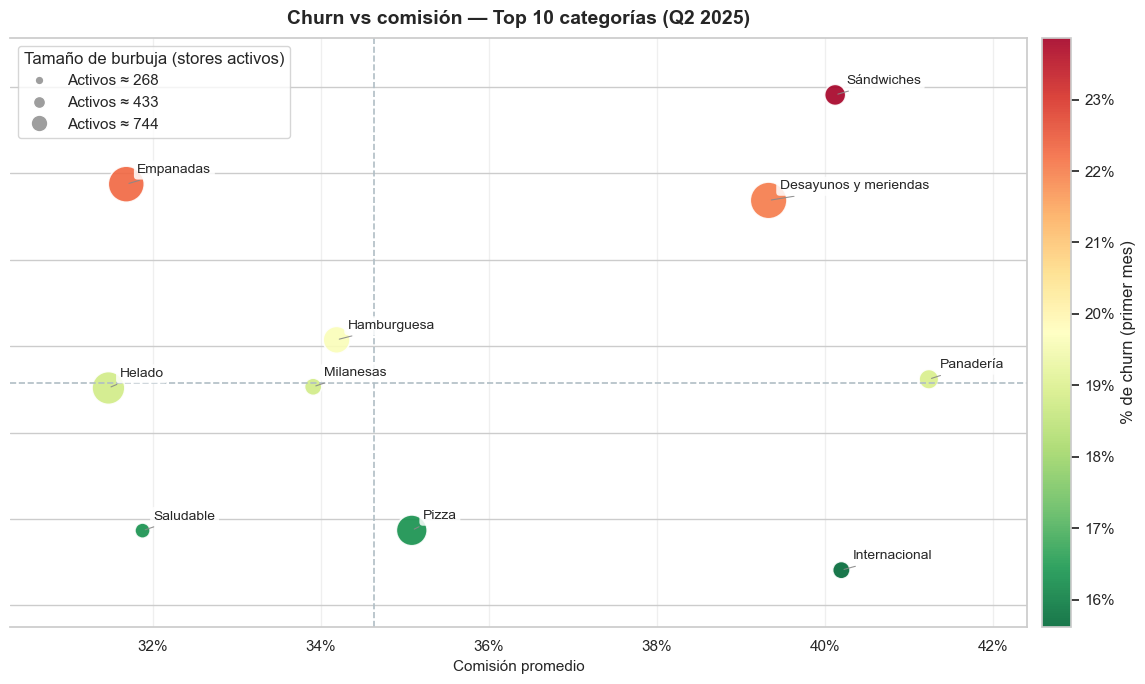

In [405]:
# Parámetros editables
YEAR   = 2025
MONTHS = [4, 5, 6]  # Q2 2025

cats_top10 = list(top_10_categories)

# Métricas por categoría
dfp = df_final[(df_final["year"] == YEAR) & (df_final["month"].isin(MONTHS))].copy()
stores_ = stores.copy()

dfp["store_id"] = dfp["store_id"].astype(str)
stores_["store_id"] = stores_["store_id"].astype(str)

dfp = dfp.merge(stores_[["store_id", "category", "comision_actual"]], on="store_id", how="left")
dfp = dfp[dfp["category"].isin(cats_top10)].copy()

# Stores activos = post-alta (churn no nulo) en el período
activos = (
    dfp[dfp["churn"].notna()]
      .groupby("category")["store_id"].nunique()
      .rename("active_stores")
)

# Churn (primer mes de racha)
churners = (
    dfp[dfp["STAGE"] == "Churn"]
      .groupby("category")["store_id"].nunique()
      .rename("churn_stores")
)

# Comisión promedio por categoría (sobre stores activos del período)
commission_avg = (
    dfp[dfp["churn"].notna()]
      .drop_duplicates("store_id")
      .groupby("category")["comision_actual"]
      .mean()
      .rename("commission_avg")
)

res = pd.concat([activos, churners, commission_avg], axis=1).fillna(0)
res["churn_rate_pct"] = np.where(
    res["active_stores"] > 0,
    100 * res["churn_stores"] / res["active_stores"],
    0.0
)

# Orden por comisión para un eje X más estable (podés cambiar a 'churn_rate_pct')
res = res.sort_values("commission_avg")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12.5, 7))

# Datos
x = res["commission_avg"].values              # comisión promedio
y = res["churn_rate_pct"].values             # % churn (primer mes)
n = res["active_stores"].values
labels = res.index.tolist()

# Tamaños y color (normalización REAL en %)
sizes = np.interp(n, (n.min() if n.min()>0 else 0, n.max() if n.max()>0 else 1), (120, 700))
norm = Normalize(vmin=np.nanmin(y), vmax=np.nanmax(y))
cmap = plt.cm.get_cmap("RdYlGn_r")

sc = ax.scatter(
    x, y, s=sizes, c=y, cmap=cmap, norm=norm,
    alpha=0.9, edgecolors="white", linewidths=1.2
)

# Etiquetas de categoría
for xi, yi, name in zip(x, y, labels):
    ax.annotate(
        name, (xi, yi),
        xytext=(8, 8), textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
        arrowprops=dict(arrowstyle="-", color="#888", lw=0.8, alpha=0.9),
        zorder=3
    )

# Título y eje X en formato %
ax.set_title("Churn vs comisión — Top 10 categorías (Q2 2025)", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Comisión promedio", fontsize=11)

# Si la comisión viene en decimales (0–1), usar formato % directo; si viene 0–100, usar PercentFormatter
if np.nanmax(x) <= 1.0:
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0%}"))
else:
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

# Ocultar completamente el eje Y izquierdo
ax.set_ylabel("")                               # sin etiqueta
ax.yaxis.set_major_locator(MaxNLocator(integer=False))
ax.set_yticklabels([])                          # sin ticks
ax.tick_params(axis="y", left=False)            # sin marcas
ax.spines["left"].set_visible(False)            # sin spine izquierdo

# Padding para aire en los extremos
xpad = (np.nanmax(x) - np.nanmin(x)) * 0.12 or 0.03
ypad = (np.nanmax(y) - np.nanmin(y)) * 0.12 or 1.0
ax.set_xlim(np.nanmin(x) - xpad, np.nanmax(x) + xpad)
ax.set_ylim(np.nanmin(y) - ypad, np.nanmax(y) + ypad)

# Líneas guía de medianas (opcionales; se mantienen para cuadrantes)
x_med = np.nanmedian(x)
y_med = np.nanmedian(y)
ax.axvline(x_med, color="#B0BEC5", lw=1.2, ls="--")
ax.axhline(y_med, color="#B0BEC5", lw=1.2, ls="--")

# Barra de color a la derecha como ÚNICA referencia de churn
cbar = plt.colorbar(sc, ax=ax, pad=0.012)
cbar.set_label("% de churn (primer mes)", rotation=90)
cbar.ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"))

# Leyenda de tamaños (stores activos)
q_vals = [int(np.quantile(n, q)) for q in (0.2, 0.5, 0.8)]
size_vals = np.interp(q_vals, (n.min() if n.min()>0 else 0, n.max() if n.max()>0 else 1), (120, 700))
handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#9E9E9E', markeredgecolor='white',
           markersize=np.sqrt(s)/2, label=f"Activos ≈ {v}")
    for s, v in zip(size_vals, q_vals)
]
leg = ax.legend(handles=handles, title="Tamaño de burbuja (stores activos)",
                loc="upper left", frameon=True)
leg._legend_box.align = "left"

ax.grid(True, axis="x", alpha=0.3)  # grid solo vertical para no confundir con la falta de eje Y
plt.tight_layout()
plt.show()


- Las categorías Helado, Hamburguesa y Empanadas tienen un alto TPN y un Churn muy bajo.
- Las categorías Sushi, Desayunos y meriendas, Pizza y Café tienen un TPN no tan alto y un Churn muy alto.

### Conectividad

In [406]:
connectivity.head()

,created_date,TOTAL_MIN_OPEN,TOTAL_MIN_PAUSED,TOTA_MIN_CLOSED,TOTAL_MINUTES_ALL,store_id,connectivity
0,2024-11-19,88.1593,0.0000,11.8407,100.0,112005,0.88
1,2024-11-19,99.1111,0.0000,0.8889,100.0,113658,0.99
2,2024-11-19,68.6111,0.0000,31.3889,100.0,111289,0.69
3,2024-11-19,89.0476,5.9524,5.0000,100.0,110933,0.89
4,2024-11-19,65.7401,34.2599,0.0000,100.0,107701,0.66


In [407]:
# Crear columna de conectividad
connectivity['connectivity'] = (connectivity['TOTAL_MIN_OPEN'] / connectivity['TOTAL_MINUTES_ALL']).round(2)
connectivity.head()

,created_date,TOTAL_MIN_OPEN,TOTAL_MIN_PAUSED,TOTA_MIN_CLOSED,TOTAL_MINUTES_ALL,store_id,connectivity
0,2024-11-19,88.1593,0.0000,11.8407,100.0,112005,0.88
1,2024-11-19,99.1111,0.0000,0.8889,100.0,113658,0.99
2,2024-11-19,68.6111,0.0000,31.3889,100.0,111289,0.69
3,2024-11-19,89.0476,5.9524,5.0000,100.0,110933,0.89
4,2024-11-19,65.7401,34.2599,0.0000,100.0,107701,0.66


Análizamos la conectividad por segmento

In [408]:
# Logging para seguimiento
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("connectivity_basic")


# Conectividad mensual por store

def make_store_month_features(connectivity: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega conectividad diaria a nivel store-mes.
    Devuelve un DF con 1 fila por (store_id, ym) y métricas simples.
    """
    log.info("Normalizando fechas y creando ym (YYYY-MM)…")
    df = connectivity.copy()
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["ym"] = df["created_date"].dt.to_period("M").astype(str)

    # Métricas: media, mediana, min, % días <0.9, <0.8, cantidad de días
    agg_dict = {
        "connectivity": ["mean", "median", "min", "std", "size",
                         lambda x: np.mean(x < 0.90),
                         lambda x: np.mean(x < 0.80)]
    }

    log.info("Agregando métricas por (store_id, ym)…")
    out = (df.groupby(["store_id", "ym"])
             .agg(agg_dict))

    out.columns = ["conn_mean","conn_median","conn_min","conn_std","days",
                   "share_days_lt_0_9","share_days_lt_0_8"]
    out = out.reset_index()

    for col in ["TOTAL_MIN_OPEN","TOTAL_MIN_PAUSED","TOTA_MIN_CLOSED","TOTAL_MINUTES_ALL"]:
        if col in df.columns:
            mins = (df.groupby(["store_id","ym"])[col].sum()
                      .rename(col.lower()))
            out = out.merge(mins.reset_index(), on=["store_id","ym"], how="left")

    return out

# Unir segmento por tienda
def attach_segment(store_month: pd.DataFrame, segments: pd.DataFrame) -> pd.DataFrame:
    """
    Une segmento por store_id. Espera columna 'segmento' en segments.
    """
    if "segmento" not in segments.columns:
        raise ValueError("El DF 'segments' debe tener una columna 'segmento'. Renombrá si es necesario.")
    log.info("Uniendo segmento por store_id…")
    out = store_month.merge(segments[["store_id","segmento"]].drop_duplicates(),
                            on="store_id", how="left")
    return out

# Agregar mensual por segmento
def make_segment_month_rollup(store_month_seg: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega a nivel (segmento, ym): promedio de conectividad y tamaño.
    """
    log.info("Agregando (segmento, ym)…")
    segm = (store_month_seg.groupby(["segmento","ym"])
                        .agg(conn_mean=("conn_mean","mean"),
                             conn_median=("conn_median","mean"),  
                             conn_min_p25=("conn_min", lambda x: x.quantile(0.25)),
                             share_lt_0_9=("share_days_lt_0_9","mean"),
                             share_lt_0_8=("share_days_lt_0_8","mean"),
                             n_stores=("store_id","nunique"))
                        .reset_index())

    segm["ym_ts"] = pd.PeriodIndex(segm["ym"], freq="M").to_timestamp()
    segm = segm.sort_values(["segmento","ym_ts"])
    return segm


def plot_segment_month_lines(segm: pd.DataFrame, value_col: str = "conn_mean", title: str = None):
    """
    Línea mensual por segmento del valor seleccionado (ej: conn_mean).
    """
    title = title or f"Evolución mensual por segmento: {value_col}"
    plt.figure()
    for seg, sub in segm.groupby("segmento"):
        plt.plot(sub["ym_ts"], sub[value_col], marker="o", label=str(seg))
    plt.title(title)
    plt.xlabel("Mes")
    plt.ylabel(value_col)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_segment_month_heatmap(segm: pd.DataFrame, value_col: str = "conn_mean", title: str = None):
    """
    Heatmap simple por (segmento x mes) mostrando la métrica elegida.
    Nota: usamos pivot + imshow; se evita seaborn por tu entorno.
    """
    title = title or f"Heatmap {value_col} por segmento y mes"
    pvt = segm.pivot(index="segmento", columns="ym", values=value_col)
    cols_sorted = sorted(pvt.columns, key=lambda s: pd.Period(s, freq="M").to_timestamp())
    pvt = pvt[cols_sorted]

    plt.figure()
    plt.imshow(pvt.values, aspect="auto")
    plt.title(title)
    plt.xlabel("Mes (YYYY-MM)")
    plt.ylabel("Segmento")
    plt.colorbar(label=value_col)
    # ticks
    plt.xticks(range(len(pvt.columns)), pvt.columns, rotation=90)
    plt.yticks(range(len(pvt.index)), pvt.index)
    plt.tight_layout()
    plt.show()


      segmento       ym  seg_conn_mean  n_stores      ym_ts
0  Microstores  2024-11       0.460716      1284 2024-11-01
1  Microstores  2024-12       0.413348      1437 2024-12-01
2  Microstores  2025-01       0.412430      1595 2025-01-01
3  Microstores  2025-02       0.435612      1796 2025-02-01
4  Microstores  2025-03       0.428362      2126 2025-03-01


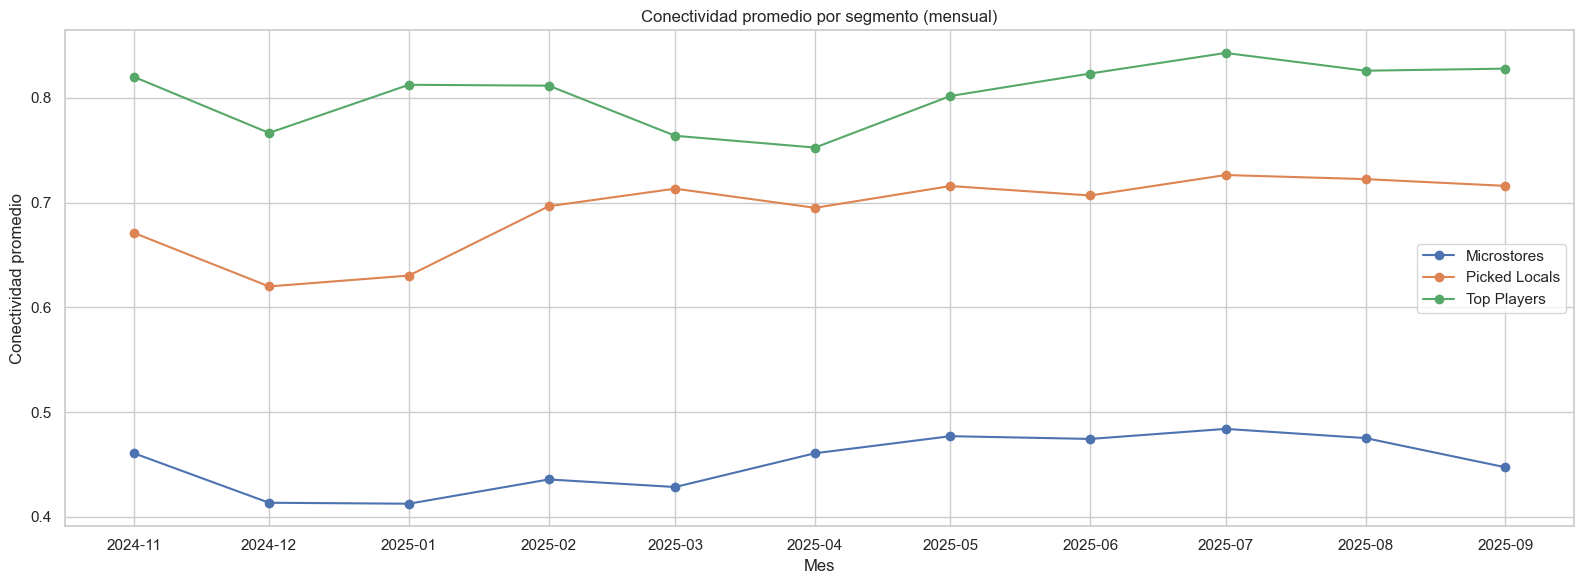

In [409]:
if "segmento" not in stores.columns and "Desc_Segmento" in stores.columns:
    stores = stores.rename(columns={"Desc_Segmento": "segmento"})

# Conectividad mensual por store
df = connectivity.copy()
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
df = df.dropna(subset=["created_date"])  
df["ym"] = df["created_date"].dt.to_period("M").astype(str)

store_month = (df.groupby(["store_id","ym"])
                 .agg(conn_mean=("connectivity","mean"))
                 .reset_index())

store_month['store_id'] = store_month['store_id'].astype(str)
stores['store_id'] = stores['store_id'].astype(str)

store_month_seg = store_month.merge(
    stores[["store_id", "segmento"]].drop_duplicates(),
    on="store_id", how="left"
)

# Promedio mensual por segmento
seg_month = (store_month_seg.groupby(["segmento","ym"])
                           .agg(seg_conn_mean=("conn_mean","mean"),
                                n_stores=("store_id","nunique"))
                           .reset_index())

seg_month["ym_ts"] = pd.PeriodIndex(seg_month["ym"], freq="M").to_timestamp()

print(seg_month.head())  


plt.figure(figsize=(16, 6)) 
for seg, sub in seg_month.groupby("segmento"):
    plt.plot(sub["ym_ts"], sub["seg_conn_mean"], marker="o", label=str(seg))
plt.title("Conectividad promedio por segmento (mensual)")
plt.xlabel("Mes")
plt.ylabel("Conectividad promedio")
plt.grid(True)
plt.legend()
plt.tight_layout()  
plt.show()

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/4080384576.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel_global = (dfm.groupby("conn_bucket")["is_churn_first"]


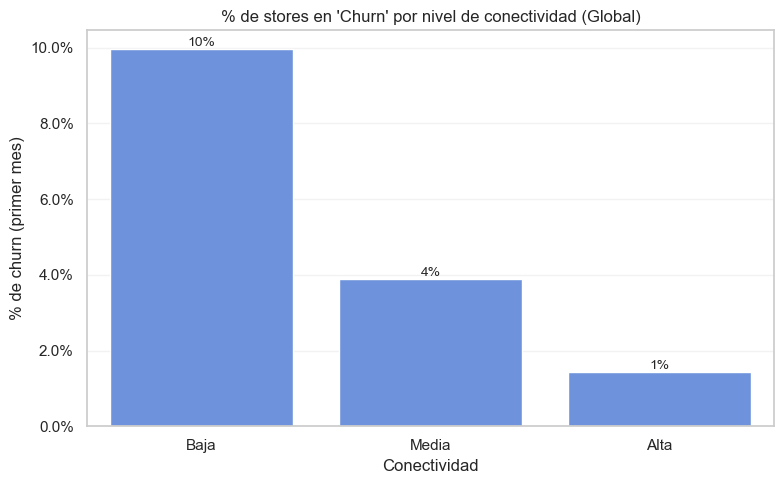

/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/4080384576.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel_seg = (dfm_top.groupby(["segmento","conn_bucket"])["is_churn_first"]


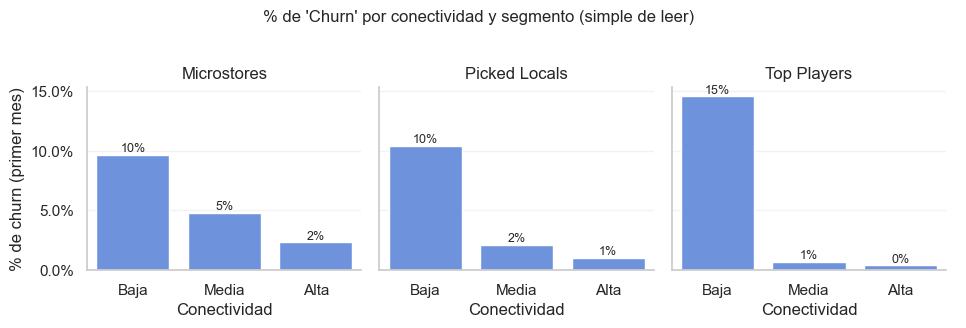

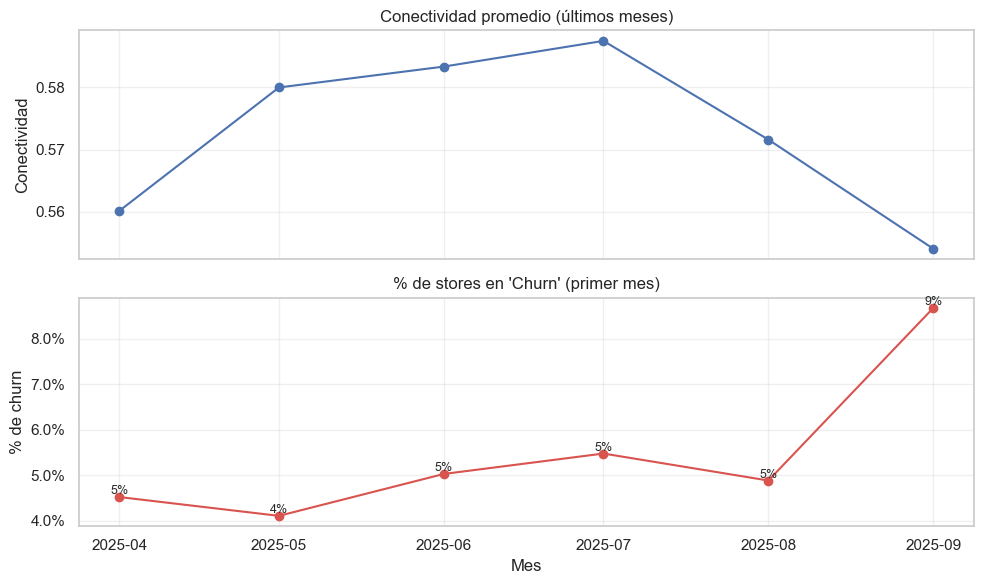

In [410]:
# Parámetros editables
ULTIMOS_MESES = 6          
NUM_SEGMENTOS = 6         
BUCKETS = 3               

if "segmento" not in stores.columns and "Desc_Segmento" in stores.columns:
    stores = stores.rename(columns={"Desc_Segmento": "segmento"})

# Conectividad mensual por store
dfc = connectivity.copy()
dfc["created_date"] = pd.to_datetime(dfc["created_date"], errors="coerce")
dfc = dfc.dropna(subset=["created_date"])
dfc["ym"] = dfc["created_date"].dt.to_period("M").astype(str)
conn_month = (dfc.groupby(["store_id","ym"])
                .agg(conn_mean=("connectivity","mean"))
                .reset_index())
conn_month["store_id"] = conn_month["store_id"].astype(str)


dff = df_final.copy()
dff["ym"] = pd.to_datetime(
    dff["year"].astype(int).astype(str) + "-" + dff["month"].astype(int).astype(str) + "-01"
).dt.to_period("M").astype(str)
dff["store_id"] = dff["store_id"].astype(str)

dfm = dff.merge(conn_month, on=["store_id","ym"], how="left")
stores_ = stores[["store_id","segmento"]].copy()
stores_["store_id"] = stores_["store_id"].astype(str)
dfm = dfm.merge(stores_, on="store_id", how="left")

dfm = dfm[dfm["churn"].notna()].copy()
dfm = dfm.dropna(subset=["conn_mean"])

# Flag churn primer mes
dfm["is_churn_first"] = (dfm["STAGE"] == "Churn").astype(int)

# Relación global (buckets Low/Med/High)
labels_map = {3: ["Baja","Media","Alta"], 4: ["Muy baja","Baja","Media","Alta"]}
dfm["conn_bucket"] = pd.qcut(dfm["conn_mean"], q=BUCKETS, labels=labels_map.get(BUCKETS, False), duplicates="drop")

rel_global = (dfm.groupby("conn_bucket")["is_churn_first"]
                .mean()
                .mul(100)
                .reset_index(name="churn_pct"))

plt.figure(figsize=(8,5))
sns.barplot(data=rel_global, x="conn_bucket", y="churn_pct", color="#5B8DEF")
plt.title("% de stores en 'Churn' por nivel de conectividad (Global)")
plt.xlabel("Conectividad")
plt.ylabel("% de churn (primer mes)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
for i, v in enumerate(rel_global["churn_pct"]):
    plt.text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=10)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Por segmento
top_segs = (dfm.groupby("segmento")["store_id"].nunique()
              .sort_values(ascending=False).head(NUM_SEGMENTOS).index)
dfm_top = dfm[dfm["segmento"].isin(top_segs)].copy()

rel_seg = (dfm_top.groupby(["segmento","conn_bucket"])["is_churn_first"]
                 .mean()
                 .mul(100)
                 .reset_index(name="churn_pct"))

g = sns.catplot(
    data=rel_seg, kind="bar",
    x="conn_bucket", y="churn_pct",
    col="segmento", col_wrap=3, sharey=True,
    color="#5B8DEF", height=3.2
)
g.set_titles("{col_name}")
g.set_xlabels("Conectividad"); g.set_ylabels("% de churn (primer mes)")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height(), f"{p.get_height():.0f}%",
                ha="center", va="bottom", fontsize=9)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle("% de 'Churn' por conectividad y segmento (simple de leer)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Evolución últimos meses
serie = (dfm.groupby("ym")
           .agg(conn_prom=("conn_mean","mean"),
                churn_pct=("is_churn_first","mean"))
           .reset_index())
serie["churn_pct"] = serie["churn_pct"]*100
serie["ym_ts"] = pd.PeriodIndex(serie["ym"], freq="M").to_timestamp()
serie = serie.sort_values("ym_ts").tail(ULTIMOS_MESES)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,6), sharex=True)
ax1.plot(serie["ym_ts"], serie["conn_prom"], marker="o")
ax1.set_title("Conectividad promedio (últimos meses)")
ax1.set_ylabel("Conectividad")
ax1.grid(True, alpha=0.3)

ax2.plot(serie["ym_ts"], serie["churn_pct"], marker="o", color="#D9534F")
ax2.set_title("% de stores en 'Churn' (primer mes)")
ax2.set_ylabel("% de churn"); ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax2.grid(True, alpha=0.3)
for x, y in zip(serie["ym_ts"], serie["churn_pct"]):
    ax2.text(x, y, f"{y:.0f}%", ha="center", va="bottom", fontsize=9)

plt.xlabel("Mes")
plt.tight_layout()
plt.show()

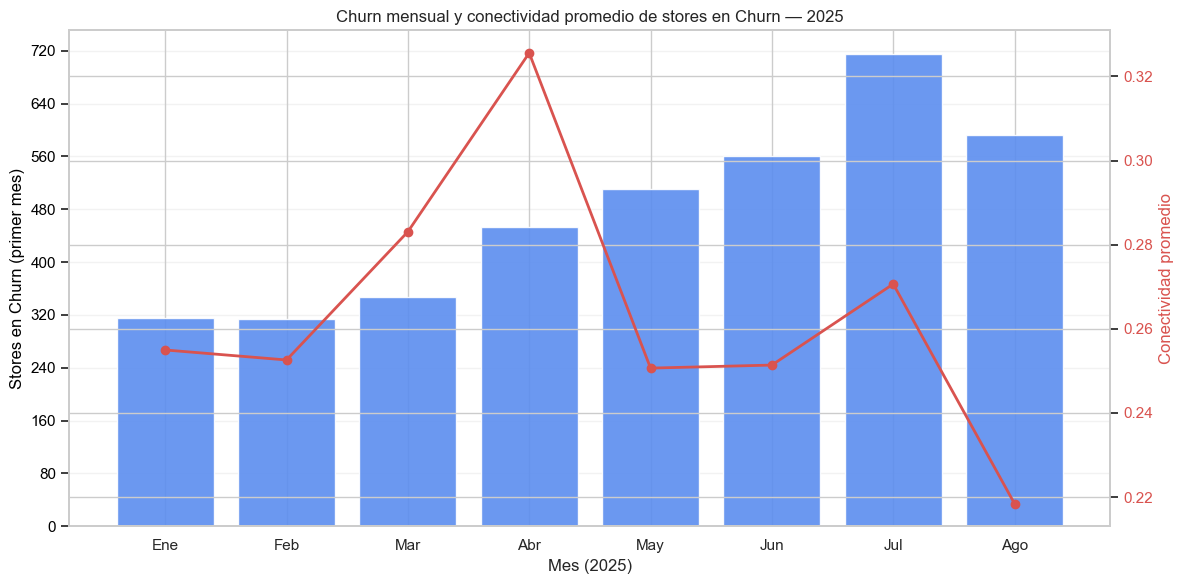

In [411]:
conn = connectivity.copy()
conn["created_date"] = pd.to_datetime(conn["created_date"], errors="coerce")
conn = conn.dropna(subset=["created_date"])
conn["ym"] = conn["created_date"].dt.to_period("M").astype(str)

conn_month = (conn.groupby(["store_id","ym"])
                .agg(conn_mean=("connectivity","mean"))
                .reset_index())

# Churn mensual  Ene–Ago 2025
dfp = df_final[(df_final["year"] == 2025) & (df_final["month"].between(1, 8))].copy()
dfp["ym"] = pd.to_datetime(
    dfp["year"].astype(int).astype(str) + "-" + dfp["month"].astype(int).astype(str) + "-01"
).dt.to_period("M").astype(str)

dfp["store_id"] = dfp["store_id"].astype(str)
conn_month["store_id"] = conn_month["store_id"].astype(str)

churn_df = dfp[dfp["STAGE"] == "Churn"].copy()

churn_with_conn = churn_df.merge(conn_month, on=["store_id","ym"], how="left")

churn_counts = (churn_df.groupby("ym")["store_id"].nunique()
                        .rename("stores_churn"))

conn_avg = (churn_with_conn.groupby("ym")["conn_mean"]
                        .mean() 
                        .rename("conn_prom_churn"))

monthly = (pd.concat([churn_counts, conn_avg], axis=1)
             .reset_index())

monthly["ts"] = pd.PeriodIndex(monthly["ym"], freq="M").to_timestamp()
monthly = monthly.sort_values("ts")
mes_labels = {"01":"Ene","02":"Feb","03":"Mar","04":"Abr","05":"May","06":"Jun","07":"Jul","08":"Ago"}
monthly["mes_lbl"] = monthly["ts"].dt.strftime("%m").map(mes_labels)

# Plot barras + línea
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras: cantidad de stores en churn (eje izquierdo)
ax1.bar(monthly["mes_lbl"], monthly["stores_churn"], color="#5B8DEF", alpha=0.9)
ax1.set_ylabel("Stores en Churn (primer mes)", color="black")
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
ax1.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax1.tick_params(axis="y", labelcolor="black")

# Línea: conectividad promedio (eje derecho)
ax2 = ax1.twinx()
ax2.plot(monthly["mes_lbl"], monthly["conn_prom_churn"], marker="o", linewidth=2.0,
         color="#D9534F", label="Conectividad prom. (stores en churn)")
ax2.set_ylabel("Conectividad promedio", color="#D9534F")
ax2.tick_params(axis="y", labelcolor="#D9534F")

ax1.set_xlabel("Mes (2025)")
plt.title("Churn mensual y conectividad promedio de stores en Churn — 2025")
ax1.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


/var/folders/k0/7nvdqhpx0t54_dcsz2cpy9nh0000gn/T/ipykernel_43609/2821423169.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel_seg = (dfm.groupby(["segmento","conn_bucket"])["is_churn_first"]


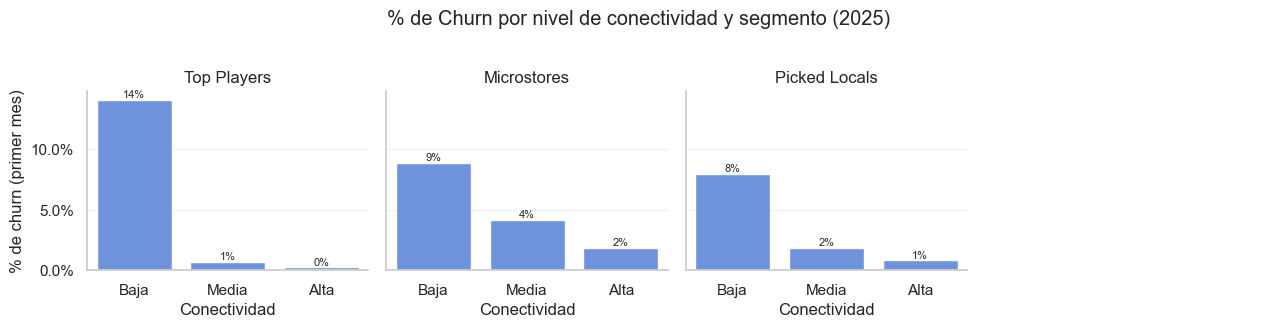

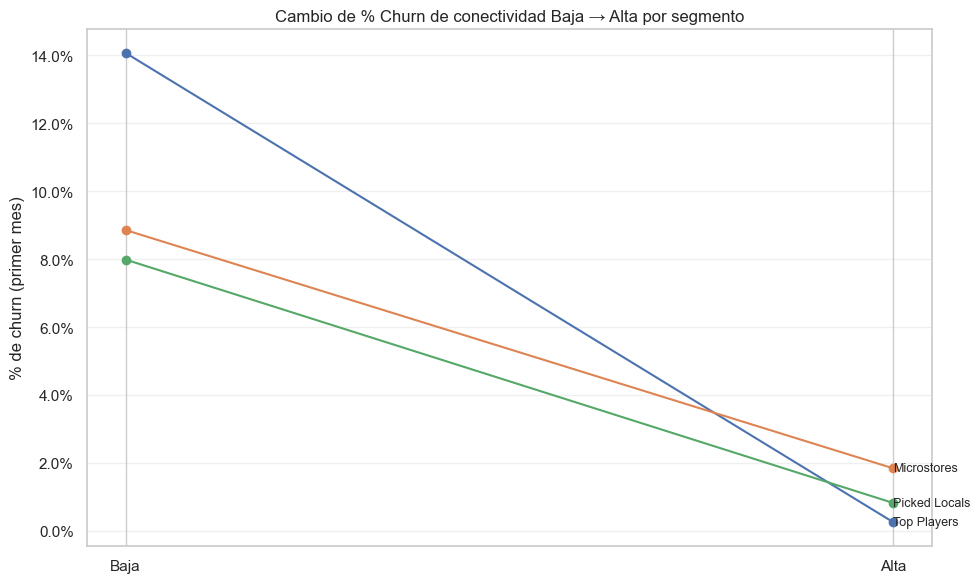

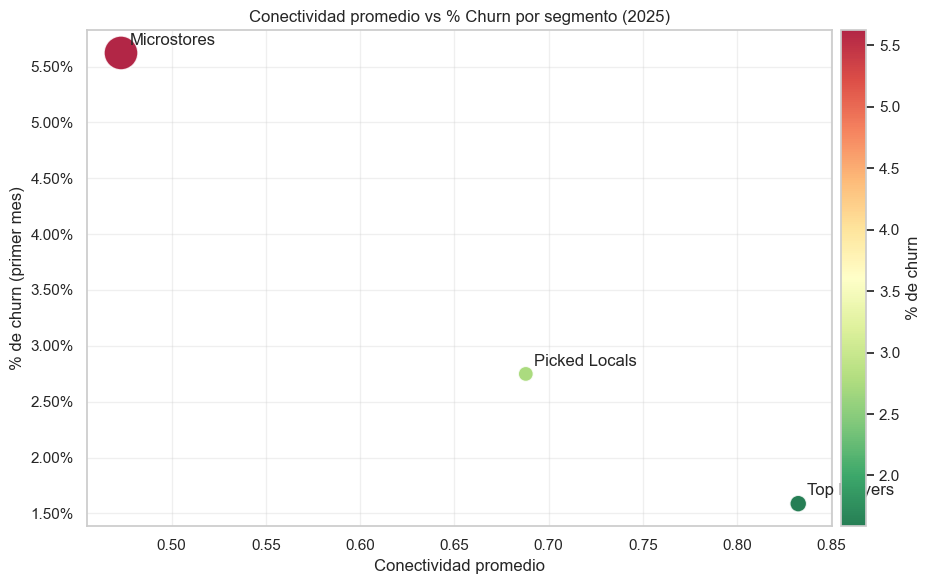

In [412]:
def prep_churn_connectivity_by_segment(df_final, connectivity, stores,
                                       year=2025, months=range(1,9), q_buckets=3):
    conn = connectivity.copy()
    conn["created_date"] = pd.to_datetime(conn["created_date"], errors="coerce")
    conn = conn.dropna(subset=["created_date"])
    conn["ym"] = conn["created_date"].dt.to_period("M").astype(str)
    conn_month = (conn.groupby(["store_id","ym"])
                    .agg(conn_mean=("connectivity","mean"))
                    .reset_index())

    dff = df_final[(df_final["year"]==year) & (df_final["month"].isin(months))].copy()
    dff["ym"] = pd.to_datetime(
        dff["year"].astype(int).astype(str) + "-" + dff["month"].astype(int).astype(str) + "-01"
    ).dt.to_period("M").astype(str)

    for c in ("store_id",):
        conn_month[c] = conn_month[c].astype(str)
        dff[c] = dff[c].astype(str)
        stores[c] = stores[c].astype(str)

    dfm = dff.merge(conn_month, on=["store_id","ym"], how="left") \
             .merge(stores[["store_id","segmento"]], on="store_id", how="left")

    dfm = dfm[dfm["churn"].notna()].dropna(subset=["conn_mean"]).copy()
    dfm["is_churn_first"] = (dfm["STAGE"]=="Churn").astype(int)

    # buckets de conectividad (Low/Med/High)
    labels_map = {3:["Baja","Media","Alta"], 4:["Muy baja","Baja","Media","Alta"]}
    dfm["conn_bucket"] = pd.qcut(dfm["conn_mean"], q=q_buckets,
                                 labels=labels_map.get(q_buckets, False),
                                 duplicates="drop")
    return dfm

dfm = prep_churn_connectivity_by_segment(df_final, connectivity, stores,
                                         year=2025, months=range(1,9), q_buckets=3)

# Barras: % Churn por bucket de conectividad dentro de cada segmento
rel_seg = (dfm.groupby(["segmento","conn_bucket"])["is_churn_first"]
             .mean().mul(100).reset_index(name="churn_pct"))

orden_segs = (rel_seg[rel_seg["conn_bucket"]=="Baja"]
                .sort_values("churn_pct", ascending=False)["segmento"])
rel_seg["segmento"] = pd.Categorical(rel_seg["segmento"], categories=orden_segs, ordered=True)

g = sns.catplot(
    data=rel_seg, kind="bar", x="conn_bucket", y="churn_pct",
    col="segmento", col_wrap=4, sharey=True, height=3.2, color="#5B8DEF"
)
g.set_titles("{col_name}")
g.set_xlabels("Conectividad"); g.set_ylabels("% de churn (primer mes)")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    for p in ax.patches:
        ax.text(p.get_x()+p.get_width()/2, p.get_height(), f"{p.get_height():.0f}%",
                ha="center", va="bottom", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle("% de Churn por nivel de conectividad y segmento (2025)", y=1.02)
plt.tight_layout()
plt.show()

# Slope chart: efecto Low - High por segmento
pivot_slope = rel_seg.pivot(index="segmento", columns="conn_bucket", values="churn_pct").reindex(orden_segs)
pivot_slope = pivot_slope[["Baja","Alta"]]  

plt.figure(figsize=(10, 6))
for seg, row in pivot_slope.iterrows():
    plt.plot(["Baja","Alta"], [row["Baja"], row["Alta"]], marker="o")
    plt.text("Alta", row["Alta"], seg, va="center", ha="left", fontsize=9)
plt.title("Cambio de % Churn de conectividad Baja → Alta por segmento")
plt.ylabel("% de churn (primer mes)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter: promedios por segmento
seg_agg = (dfm.groupby("segmento")
             .agg(conn_avg=("conn_mean","mean"),
                  churn_pct=("is_churn_first","mean"),
                  activos=("store_id","nunique"))
             .reset_index())
seg_agg["churn_pct"] *= 100

fig, ax = plt.subplots(figsize=(10,6))
sizes = np.interp(seg_agg["activos"], (seg_agg["activos"].min(), seg_agg["activos"].max()), (120, 600))
sc = ax.scatter(seg_agg["conn_avg"], seg_agg["churn_pct"], s=sizes, alpha=0.85,
                edgecolors="white", linewidths=1.1, c=seg_agg["churn_pct"], cmap="RdYlGn_r")
for xi, yi, name in zip(seg_agg["conn_avg"], seg_agg["churn_pct"], seg_agg["segmento"]):
    ax.annotate(name, (xi, yi), xytext=(6,6), textcoords="offset points")
ax.set_title("Conectividad promedio vs % Churn por segmento (2025)")
ax.set_xlabel("Conectividad promedio")
ax.set_ylabel("% de churn (primer mes)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.colorbar(sc, ax=ax, pad=0.01, label="% de churn")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
